# Bölüm 6 — Topluluk Öğrenimi ve Rastgele Ormanlar

> 📘 Bu notebook, **"Hands-On Machine Learning with Scikit-Learn and PyTorch"** kitabının 6. bölümünün Türkçe çevirisi ve detaylı açıklamasıdır.

---

## Kitaptaki Anlatımın İçeriği

1. [Temel Fikir: Kalabalığın Bilgeliği](#1-temel-fikir)
2. [Oylama Sınıflandırıcıları (Voting Classifiers)](#2-oylama)
3. [Bagging ve Pasting](#3-bagging-pasting)
4. [Rastgele Ormanlar (Random Forests)](#4-rastgele-ormanlar)
5. [Güçlendirme (Boosting)](#5-boosting)
6. [Yığınlama (Stacking)](#6-stacking)
7. [Özet ve Ne Zaman Hangisini Kullanmalı?](#7-ozet)


---

## 📋 https://github.com/ageron/handson-mlp paylaşılan kod kısmının detaylı açıklaması

Bu kısım, bölümün tüm örnek kodlarını ve alıştırma çözümlerini **Türkçe, ayrıntılı açıklamalarla** içermektedir.

### Konular
1. [Kurulum](#kurulum)
2. [Oylama Sınıflandırıcıları](#oylama)
3. [Bagging ve Pasting](#bagging)
4. [Rastgele Ormanlar](#random-forest)
5. [Boosting — AdaBoost](#adaboost)
6. [Gradient Boosting](#gradient-boosting)
7. [Histogram Tabanlı Gradient Boosting](#hgb)
8. [Stacking](#stacking)
9. [Alıştırma Çözümleri 1–7](#cevaplar)
10. [Alıştırma 8 — MNIST Oylama Sınıflandırıcısı](#mnist-voting)
11. [Alıştırma 9 — MNIST Stacking](#mnist-stacking)

---

---

## 1. Temel Fikir: Kalabalığın Bilgeliği <a id='1-temel-fikir'></a>

Binlerce kişiye karmaşık bir soru sorup cevaplarını birleştirdiğinizde, çoğu zaman tek bir uzmanın cevabından **çok daha iyi** bir sonuç elde edersiniz. Buna **"kalabalığın bilgeliği" (wisdom of the crowd)** denir.

Makine öğreniminde de aynı prensip geçerlidir:

> Birden fazla modelin (sınıflandırıcı veya regresör) tahminlerini birleştirirseniz, tek başına en iyi modelden bile **daha doğru** sonuçlar elde edebilirsiniz.

Bu tahminleyici grubuna **topluluk (ensemble)**, bu tekniğe ise **topluluk öğrenimi (ensemble learning)** denir. Topluluk öğrenimi yöntemleri ise **topluluk yöntemi (ensemble method)** olarak adlandırılır.

### Örnek: Rastgele Orman

Eğitim setinin farklı rastgele alt kümelerinde eğitilmiş bir grup karar ağacı sınıflandırıcısı oluşturabilirsiniz. Her ağacın tahminlerini alıp en çok oy alan sınıfı topluluğun tahmini olarak seçebilirsiniz. Bu yapıya **Rastgele Orman (Random Forest)** denir; ve günümüzün en güçlü makine öğrenimi algoritmalarından biridir.

### Ne Zaman Kullanılır?

Proje sonlarında, birkaç iyi tahminleyici inşa ettikten sonra, bunları daha da iyi bir tahminleyicide birleştirmek için topluluk yöntemleri sıkça kullanılır. Netflix Ödülü yarışması gibi büyük ML yarışmalarında kazanan çözümlerin neredeyse tamamı topluluk yöntemlerini içermekteydi.

### Dezavantajlar

- Tek bir modele göre çok daha fazla hesaplama kaynağı (eğitim ve çıkarım için) gerektirir.
- Dağıtımı ve yönetimi daha karmaşıktır.
- Tahminlerin yorumlanması güçtür.

Ancak artılar genellikle eksilerin önüne geçer.

---

## 2. Oylama Sınıflandırıcıları (Voting Classifiers) <a id='2-oylama'></a>

Diyelim ki, her biri yaklaşık %80 doğruluk elde eden birkaç sınıflandırıcı eğittiniz:
- Lojistik Regresyon Sınıflandırıcısı
- SVM Sınıflandırıcısı
- Rastgele Orman Sınıflandırıcısı
- K-En Yakın Komşu Sınıflandırıcısı
- ve belki birkaç tane daha...

### 2.1 Hard Voting (Sert/Çoğunluk Oylaması)

Her sınıflandırıcının tahminini alıp **en çok oy alan sınıfı** topluluğun tahmini yapmak, çok basit ama güçlü bir yöntemdir. Bu çoğunluk oyu sınıflandırıcısına **hard voting classifier (sert oylama sınıflandırıcısı)** denir.

Şaşırtıcı biçimde, bu oylama sınıflandırıcısı çoğu zaman topluluktaki en iyi sınıflandırıcıdan daha yüksek doğruluk elde eder!

Hatta her sınıflandırıcı **zayıf öğrenici** (weak learner — rastgele tahminden biraz daha iyi) olsa bile, toplulukta yeterli sayıda ve birbirinden **yeterince farklı** zayıf öğrenici olduğu sürece topluluk **güçlü bir öğrenici** (strong learner) haline gelebilir.

#### 🪙 Para Analojisi

Hafifçe taraflı bir para düşünün: tura gelme ihtimali %51, yazı ihtimali %49. Bu parayı 1.000 kez attığınızda çoğunlukla 510 tura, 490 yazı elde edersiniz. Matematiği yaparsanız, 1.000 atışta **çoğunluğun tura gelmesi olasılığının yaklaşık %75** olduğunu görürsünüz. 10.000 atışta bu oran %97'nin üzerine çıkar. Bu **büyük sayılar yasası**ndan (law of large numbers) kaynaklanır.

Topluluk öğrenimi de benzer şekilde çalışır: yeterince çok ve çeşitli tahminleyici varsa, küçük avantajlar büyük kazanımlara dönüşür.

> ⚠️ **Önemli Not:** Bu durum yalnızca tüm sınıflandırıcıların **birbirinden bağımsız** (farklı hata türleri yapan) olması durumunda geçerlidir. Eğer aynı verilerle eğitilirlerse benzer hatalar yapmaları olasıdır.

> 💡 **İpucu:** Topluluk yöntemleri, tahminleyiciler birbirinden ne kadar bağımsızsa o kadar iyi çalışır. Çeşitlilik sağlamanın bir yolu, **farklı algoritmalar** kullanmaktır. Bu, farklı türde hatalar yapma şansını artırarak topluluğun doğruluğunu iyileştirir.

In [1]:
# Gerekli kütüphaneleri içe aktaralım
from sklearn.datasets import make_moons
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# Moons veri setini oluşturup eğitim/test olarak bölelim
X, y = make_moons(n_samples=500, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Hard Voting Classifier oluşturalım
# Üç farklı sınıflandırıcıyı birleştiriyoruz
voting_clf = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(random_state=42)),       # Lojistik Regresyon
        ('rf', RandomForestClassifier(random_state=42)),   # Rastgele Orman
        ('svc', SVC(random_state=42))                       # Destek Vektör Makinesi
    ]
)
voting_clf.fit(X_train, y_train)

ModuleNotFoundError: No module named 'sklearn'

In [2]:
# Her sınıflandırıcının test seti üzerindeki doğruluğuna bakalım
for name, clf in voting_clf.named_estimators_.items():
    print(f"{name:5s} doğruluğu = {clf.score(X_test, y_test):.3f}")

# Beklenen çıktı:
# lr    doğruluğu = 0.864
# rf    doğruluğu = 0.896
# svc   doğruluğu = 0.896

lr    doğruluğu = 0.864
rf    doğruluğu = 0.896
svc   doğruluğu = 0.896


In [3]:
# Oylama sınıflandırıcısının genel doğruluğuna bakalım
print(f"Hard Voting Classifier doğruluğu = {voting_clf.score(X_test, y_test):.3f}")
# Beklenen çıktı: 0.912
# Bireysel sınıflandırıcıların üzerinde! ✅

# İlk test örneğinin tahmini:
print("\nİlk örnek için tahminler:")
print("Topluluk tahmini:", voting_clf.predict(X_test[:1]))
print("Bireysel tahminler:", [clf.predict(X_test[:1]) for clf in voting_clf.estimators_])
# LR ve RF sınıf=1 tahmin ederken SVC sınıf=0 tahmin eder -> çoğunluk 1 kazanır

Hard Voting Classifier doğruluğu = 0.912

İlk örnek için tahminler:
Topluluk tahmini: [1]
Bireysel tahminler: [array([1]), array([1]), array([0])]


### 2.2 Soft Voting (Yumuşak Oylama)

Tüm sınıflandırıcılar **sınıf olasılığı** tahmin edebiliyorsa (yani `predict_proba()` metoduna sahiplerse), her sınıf için **ortalama olasılık** hesaplanır ve en yüksek ortalama olasılığa sahip sınıf seçilir. Bu yönteme **soft voting (yumuşak oylama)** denir.

Soft voting genellikle hard voting'den **daha iyi** performans gösterir, çünkü yüksek güvenle yapılan oyları daha fazla ağırlıklandırır.

> 💡 **İpucu:** Soft voting, tahmin edilen olasılıklar iyi kalibre edildiğinde en iyi şekilde çalışır. Değilse `sklearn.calibration.CalibratedClassifierCV` kullanarak kalibre edebilirsiniz.

**SVC** sınıfı varsayılan olarak olasılık tahmin etmez. Etkinleştirmek için `probability=True` parametresi gerekir (bu çapraz doğrulama kullanarak olasılıkları tahmin eder, eğitimi biraz yavaşlatır).

In [5]:
# Soft Voting'e geçelim
voting_clf.voting = "soft"                              # Yumuşak oylama modu
voting_clf.named_estimators["svc"].probability = True  # SVC için olasılık tahmini aç

voting_clf.fit(X_train, y_train)
print(f"Soft Voting Classifier doğruluğu = {voting_clf.score(X_test, y_test):.3f}")
# Beklenen çıktı: 0.92 -> Hard voting'den (%91.2) daha iyi! ✅# Soft Voting'e geçelim


Soft Voting Classifier doğruluğu = 0.920


---

## 3. Bagging ve Pasting <a id='3-bagging-pasting'></a>

Farklı sınıflandırıcı türleri kullanmak yerine, **aynı algoritmayı** eğitim setinin **farklı rastgele alt kümelerinde** eğitmek de model çeşitliliği sağlar.

| Yöntem | Örnekleme Yöntemi | Açıklama |
|--------|------------------|----------|
| **Bagging** | **Yerine koyarak** (with replacement) | Bootstrap Aggregating — aynı örnek birden fazla kez seçilebilir |
| **Pasting** | **Yerine koymadan** (without replacement) | Her örnek her tahminleyici için en fazla bir kez seçilir |

Her iki yöntemde de tahminler birleştirilir:
- **Sınıflandırma:** İstatistiksel mod (en sık tahmin) — hard voting gibi
- **Regresyon:** Ortalama

### Neden Çalışır?

Her bireysel tahminleyici, tam eğitim setinde eğitilene göre **daha yüksek yanlılıkla (bias)** çalışır. Ancak birleştirme işlemi hem **yanlılığı hem de varyansı düşürür**.

**Sezgi örneği:** İki regresör düşünün:
- İlki ortalama **40.000 TL eksik** tahmin ediyor
- İkincisi ortalama **50.000 TL fazla** tahmin ediyor

İkisinin ortalaması alınırsa hata = (-40.000 + 50.000) / 2 = **5.000 TL** — çok daha düşük!

Varyans da aynı şekilde düşer: Her ikisinin standart sapması 10.000 TL ise, ortalamanın standart sapması ≈ 7.071 TL olur.

> 💡 **İpucu:** Verileriniz gürültülüyse veya modeliniz aşırı öğrenmeye (overfitting) eğilimliyse **Bagging** tercih edin. Aksi takdirde **Pasting** tercih edin — eğitim sırasında tekrarı önler ve biraz daha hesaplama verimlidir.

### Paralel Eğitim Avantajı

Tüm tahminleyiciler **paralel** olarak eğitilebilir (farklı CPU çekirdekleri veya sunucular aracılığıyla). Tahminler de paralel yapılabilir. Bu nedenle Bagging ve Pasting **çok iyi ölçeklenen** yöntemlerdir.

In [6]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

# 500 Karar Ağacından oluşan bir Bagging topluluğu eğitelim
# Her ağaç, eğitim setinden yerine koyarak rastgele seçilmiş 100 örnek üzerinde eğitilir
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(),  # Temel tahminleyici
    n_estimators=500,          # 500 ağaç
    max_samples=100,           # Her ağaç için 100 örnek
    n_jobs=-1,                 # Tüm CPU çekirdeklerini kullan
    random_state=42
    # bootstrap=True (varsayılan) → Bagging
    # bootstrap=False olsaydı → Pasting
)
bag_clf.fit(X_train, y_train)
print(f"Bagging Classifier doğruluğu = {bag_clf.score(X_test, y_test):.3f}")

Bagging Classifier doğruluğu = 0.904


### 3.1 OOB (Out-of-Bag — Torba Dışı) Değerlendirme

Bagging'de, her tahminleyici için eğitim örneklerinin yaklaşık **%37'si hiç seçilmez**. Bu seçilmeyen örneklere **OOB (out-of-bag — torba dışı)** örnekleri denir.

Bu örnekler, ayrı bir doğrulama seti oluşturmaya gerek kalmadan topluluğu değerlendirmek için kullanılabilir. Yeterli sayıda tahminleyici varsa, eğitim setindeki her örnek birden fazla tahminleyici için OOB örneği olacaktır; bu tahminleyiciler kullanılarak o örnek için adil bir tahmin yapılabilir.

Matematiksel kanıt: *m* eğitim örneği yerine koyarak örneklendiğinde, her bir örneğin herhangi bir tahminleyici tarafından **seçilmeme** olasılığı → `(1 - 1/m)^m` → büyük *m* için ≈ `e^(-1) ≈ 0.368` yani yaklaşık **%63'ü seçilir, %37'si seçilmez**.

In [7]:
from sklearn.metrics import accuracy_score

# OOB değerlendirmesi ile Bagging Classifier
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(),
    n_estimators=500,
    oob_score=True,    # Eğitim sonrası otomatik OOB değerlendirmesi yap
    n_jobs=-1,
    random_state=42
)
bag_clf.fit(X_train, y_train)

print(f"OOB Skoru (eğitim seti üzerinde): {bag_clf.oob_score_:.3f}")
# Beklenen çıktı: 0.896

# Gerçek test doğruluğu
y_pred = bag_clf.predict(X_test)
print(f"Test Seti Doğruluğu: {accuracy_score(y_test, y_pred):.3f}")
# Beklenen çıktı: 0.912 — OOB biraz kötümser bir tahmin yapmış

# İlk 3 eğitim örneği için OOB karar fonksiyonu (sınıf olasılıkları)
print("\nİlk 3 örnek için OOB olasılıkları:")
print(bag_clf.oob_decision_function_[:3])

OOB Skoru (eğitim seti üzerinde): 0.896
Test Seti Doğruluğu: 0.920

İlk 3 örnek için OOB olasılıkları:
[[0.32352941 0.67647059]
 [0.3375     0.6625    ]
 [1.         0.        ]]


### 3.2 Rastgele Yamalar (Random Patches) ve Rastgele Alt Uzaylar (Random Subspaces)

`BaggingClassifier`, örneklerin yanı sıra **özellikleri** (features) de örnekleyebilir. Bu, iki hiperparametre ile kontrol edilir: `max_features` ve `bootstrap_features`.

| Yöntem | Örnek Örnekleme | Özellik Örnekleme | Kullanım Senaryosu |
|--------|----------------|-------------------|--------------------|
| **Random Patches** | Evet | Evet | Görüntüler gibi yüksek boyutlu girdiler |
| **Random Subspaces** | Hayır (tümü) | Evet | Özellik çeşitliliği istendiğinde |

Özellik örneklemesi, tahminleyiciler arasında daha fazla çeşitlilik yaratır. Biraz daha fazla yanlılık karşılığında daha düşük varyans elde edilir.

In [8]:
# Random Patches örneği: hem örnek hem özellik örneklemesi
random_patches_clf = BaggingClassifier(
    DecisionTreeClassifier(),
    n_estimators=500,
    max_samples=0.8,           # Örneklerin %80'ini kullan
    bootstrap=True,            # Yerine koyarak örnekle
    max_features=0.8,          # Özelliklerin %80'ini kullan
    bootstrap_features=True,   # Özellikleri de yerine koyarak örnekle
    n_jobs=-1,
    random_state=42
)
random_patches_clf.fit(X_train, y_train)
print(f"Random Patches Classifier doğruluğu = {random_patches_clf.score(X_test, y_test):.3f}")

# Random Subspaces örneği: tüm örnekler ama özellik örneklemesi
random_subspaces_clf = BaggingClassifier(
    DecisionTreeClassifier(),
    n_estimators=500,
    max_samples=1.0,           # Tüm örnekleri kullan
    bootstrap=False,           # Yerine koymadan (pasting)
    max_features=0.8,          # Özelliklerin %80'ini kullan
    bootstrap_features=True,   # Özellikleri yerine koyarak örnekle
    n_jobs=-1,
    random_state=42
)
random_subspaces_clf.fit(X_train, y_train)
print(f"Random Subspaces Classifier doğruluğu = {random_subspaces_clf.score(X_test, y_test):.3f}")

Random Patches Classifier doğruluğu = 0.832
Random Subspaces Classifier doğruluğu = 0.648


---

## 4. Rastgele Ormanlar (Random Forests) <a id='4-rastgele-ormanlar'></a>

**Rastgele Orman**, genellikle bagging yöntemi (bazen pasting) ile eğitilen bir karar ağaçları topluluğudur. Tipik olarak `max_samples` eğitim setinin boyutuna eşit olarak ayarlanır.

Scikit-Learn, karar ağaçları için optimize edilmiş `RandomForestClassifier` (ve regresyon için `RandomForestRegressor`) sınıflarını sağlar. Bunlar, `BaggingClassifier` içinde `DecisionTreeClassifier` kullanmaktan daha uygun ve verimlidir.

### Rastgele Ormanların Ekstra Rastgeleliği

`RandomForestClassifier`, ağaçları büyütürken **ekstra rastgelelik** ekler:

- Normal karar ağaçlarında: her düğümde en iyi bölünmeyi sağlayan özellik aranır
- Rastgele Ormanda: her düğümde **rastgele bir özellik alt kümesi** arasından en iyi bölünme aranır

Varsayılan olarak `√n` özellik (n: toplam özellik sayısı) örneklenir. Bu, daha fazla ağaç çeşitliliği sağlar ve yüksek yanlılık karşılığında daha düşük varyans elde edilir — genel olarak daha iyi bir model ortaya çıkar.

In [9]:
from sklearn.ensemble import RandomForestClassifier

# 500 ağaçlık, her ağaç maksimum 16 yaprak düğümüyle sınırlandırılmış
# Rastgele Orman Sınıflandırıcısı
rnd_clf = RandomForestClassifier(
    n_estimators=500,     # 500 karar ağacı
    max_leaf_nodes=16,    # Her ağaç en fazla 16 yaprak düğümüne sahip olabilir
    n_jobs=-1,            # Tüm CPU çekirdeklerini kullan
    random_state=42
)
rnd_clf.fit(X_train, y_train)
y_pred_rf = rnd_clf.predict(X_test)
print(f"Random Forest Classifier doğruluğu = {accuracy_score(y_test, y_pred_rf):.3f}")

# Not: Yukarıdaki RandomForestClassifier, aşağıdaki BaggingClassifier ile eşdeğerdir:
# bag_clf = BaggingClassifier(
#     DecisionTreeClassifier(max_features="sqrt", max_leaf_nodes=16),
#     n_estimators=500, n_jobs=-1, random_state=42
# )

Random Forest Classifier doğruluğu = 0.912


### 4.1 Extra-Trees (Aşırı Rastgele Ağaçlar)

Rastgele Ormanda her düğümde rastgele bir özellik alt kümesi kullanılır. Bu rastgeleliği daha da artırmak için, her özellik için **en iyi eşiği aramak yerine rastgele eşikler** de kullanılabilir.

Bu tür aşırı rastgele ağaçlardan oluşan bir ormana **Extra-Trees (Extremely Randomized Trees — Aşırı Rastgele Ağaçlar)** topluluğu denir.

**Avantajları:**
- Normal Rastgele Ormanlardan **çok daha hızlı** eğitilir (her düğümde en iyi eşiği aramak en yavaş adımdır, bu adım ortadan kalkar)
- Aşırı öğrenme sorunuyla karşılaşıldığında, özellikle gürültülü ve/veya yüksek boyutlu veri setlerinde daha iyi performans gösterebilir
- Daha fazla yanlılık karşılığında daha düşük varyans elde edilir

> 💡 **İpucu:** Son Scikit-Learn sürümlerinde karar ağacı, rastgele orman ve extra-trees sınıfları eksik değerleri (missing values) doğal olarak destekler — imputer gerekmez!

In [10]:
from sklearn.ensemble import ExtraTreesClassifier

# Extra-Trees Sınıflandırıcısı
# API'si RandomForestClassifier ile aynı, fark: bootstrap=False (varsayılan)
extra_clf = ExtraTreesClassifier(
    n_estimators=500,
    max_leaf_nodes=16,
    n_jobs=-1,
    random_state=42
)
extra_clf.fit(X_train, y_train)
print(f"Extra-Trees Classifier doğruluğu = {extra_clf.score(X_test, y_test):.3f}")

Extra-Trees Classifier doğruluğu = 0.912


### 4.2 Özellik Önemi (Feature Importance)

Rastgele Ormanların büyük bir avantajı, her özelliğin **görece önemini** kolayca ölçebilmesidir.

Scikit-Learn, bir özelliğin önemini, o özelliği kullanan ağaç düğümlerinin ormandaki tüm ağaçlar boyunca **safsızlığı (impurity) ortalama ne kadar azalttığına** bakarak ölçer. Daha kesin olmak gerekirse, her düğümün ağırlığı o düğümle ilişkili eğitim örneği sayısına eşittir.

Scikit-Learn eğitimden sonra bu skoru otomatik olarak hesaplar ve `feature_importances_` özelliği aracılığıyla erişilebilir hale getirir.

🌸 Iris Veri Seti — Özellik Önemleri:
---------------------------------------------
  sepal length (cm)        : 0.11 (11.2%)
  sepal width (cm)         : 0.02 (2.3%)
  petal length (cm)        : 0.44 (44.1%)
  petal width (cm)         : 0.42 (42.3%)


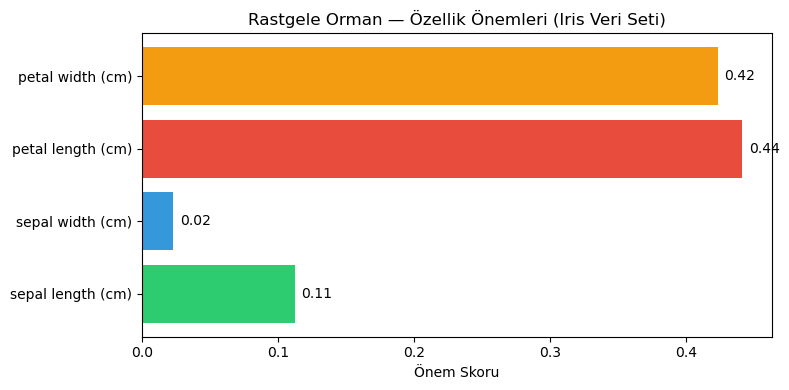

In [11]:
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

# Iris veri seti üzerinde Rastgele Orman eğitelim ve özellik önemlerini görelim
iris = load_iris(as_frame=True)
rnd_clf_iris = RandomForestClassifier(n_estimators=500, random_state=42)
rnd_clf_iris.fit(iris.data, iris.target)

print("🌸 Iris Veri Seti — Özellik Önemleri:")
print("-" * 45)
for score, name in zip(rnd_clf_iris.feature_importances_, iris.data.columns):
    print(f"  {name:25s}: {score:.2f} ({score*100:.1f}%)")

# Görselleştirme
fig, ax = plt.subplots(figsize=(8, 4))
importances = rnd_clf_iris.feature_importances_
feature_names = iris.data.columns
bars = ax.barh(feature_names, importances, color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'])
ax.set_xlabel('Önem Skoru')
ax.set_title('Rastgele Orman — Özellik Önemleri (Iris Veri Seti)')
for bar, val in zip(bars, importances):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

# Sonuç: Taç yaprağı uzunluğu (%44) ve genişliği (%42) en önemli özellikler
# Çanak yaprak uzunluğu (%11) ve genişliği (%2) görece önemsiz

> 📊 **Not:** Rastgele Ormanlar, hangi özelliklerin önemli olduğunu hızlıca anlamak için çok kullanışlıdır. Özellikle özellik seçimi (feature selection) yapmanız gerektiğinde büyük kolaylık sağlar.
>
> MNIST veri seti üzerinde eğitilmiş bir Rastgele Orman, her pikselin önemini hesaplayabilir ve görselleştirerek hangi piksel bölgelerinin rakam tanıma için kritik olduğunu gösterebilir.

---

## 5. Güçlendirme (Boosting) <a id='5-boosting'></a>

**Boosting (Güçlendirme)** — özgün adıyla *hypothesis boosting* — birkaç zayıf öğreniciyi güçlü bir öğreniciye dönüştürebilen herhangi bir topluluk yöntemine verilen addır.

Çoğu boosting yönteminin genel fikri şudur: **tahminleyicileri sıralı olarak eğitmek**, her biri bir öncekinin hatalarını düzeltmeye çalışmak.

> ⚠️ **Önemli Uyarı:** Sıralı eğitim, eğitimin paralelleştirilmesini engeller. Bu nedenle Boosting, Bagging veya Pasting kadar iyi ölçeklenemez.

En popüler iki Boosting yöntemi:
1. **AdaBoost** (Adaptive Boosting — Uyarlamalı Güçlendirme)
2. **Gradient Boosting** (Gradyan Güçlendirme)

### 5.1 AdaBoost (Uyarlamalı Güçlendirme)

Yeni bir tahminleyicinin öncekini düzeltmesinin bir yolu, öncekinin **yetersiz öğrendiği** (underfit ettiği) eğitim örneklerine **daha fazla dikkat** etmektir. Bu, yeni tahminleyicilerin giderek daha zor vakalara odaklanmasıyla sonuçlanır. AdaBoost bu tekniği kullanır.

**AdaBoost Algoritması — Adım Adım:**

1. **Başlangıç:** Her eğitim örneğinin ağırlığı `w(i) = 1/m` olarak ayarlanır (toplamları 1).
2. **İlk tahminleyici eğitilir** ve ağırlıklı hata oranı `r₁` hesaplanır.
3. **Tahminleyici ağırlığı** `αⱼ` hesaplanır: doğru tahminleyicilerin ağırlığı yüksek, yanlış tahminleyicilerin ağırlığı negatife dönebilir.
4. **Örnek ağırlıkları güncellenir:** Yanlış sınıflandırılan örneklerin ağırlıkları artırılır.
5. Ağırlıklar normalize edilir (toplamları 1 olacak şekilde).
6. **Yeni tahminleyici** güncellenmiş ağırlıklarla eğitilir ve süreç tekrar eder.
7. Süreç istenilen tahminleyici sayısına ulaşıldığında veya mükemmel bir tahminleyici bulunduğunda durur.

**Tahmin yapma:** Tüm tahminleyicilerin tahminleri, tahminleyici ağırlıkları `αⱼ` kullanılarak ağırlıklı oy ile birleştirilir.

**Formüller:**

$$r_j = \frac{\sum_{i=1, \hat{y}_j^{(i)} \neq y^{(i)}}^{m} w^{(i)}}{\sum_{i=1}^{m} w^{(i)}}$$

$$\alpha_j = \eta \cdot \log\frac{1-r_j}{r_j}$$

$$w^{(i)} \leftarrow \begin{cases} w^{(i)} & \text{eğer } \hat{y}_j^{(i)} = y^{(i)} \\ w^{(i)} \cdot \exp(\alpha_j) & \text{eğer } \hat{y}_j^{(i)} \neq y^{(i)} \end{cases}$$

Scikit-Learn, AdaBoost'un çok sınıflı versiyonu olan **SAMME** (*Stagewise Additive Modeling using a Multiclass Exponential loss function*) algoritmasını kullanır.

> 💡 **İpucu:** AdaBoost topluluğunuz eğitim setine aşırı öğreniyorsa (overfitting), tahminleyici sayısını azaltmayı veya temel tahminleyiciyi daha güçlü düzenleştirmeyi deneyin.

In [12]:
from sklearn.ensemble import AdaBoostClassifier

# 30 Decision Stump (max_depth=1 Karar Ağacı) kullanan AdaBoost
# Decision Stump: tek bir karar düğümü + iki yaprak düğümünden oluşan minimal ağaç
ada_clf = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1),  # Decision Stump (Karar Güdük)
    n_estimators=30,       # 30 tahminleyici
    learning_rate=0.5,     # Öğrenme oranı — misclassified örneklerin ağırlık artışını ölçekler
    random_state=42,
    algorithm="SAMME"      # Çok sınıflı AdaBoost algoritması
)
ada_clf.fit(X_train, y_train)
print(f"AdaBoost Classifier doğruluğu = {ada_clf.score(X_test, y_test):.3f}")

AdaBoost Classifier doğruluğu = 0.880


### 5.2 Gradient Boosting (Gradyan Güçlendirme)

Bir diğer çok popüler güçlendirme algoritması **Gradient Boosting**'dir. AdaBoost gibi tahminleyicileri sıralı olarak ekler, her biri bir öncekini düzeltmeye çalışır. Ancak AdaBoost'tan farkı şudur:

- **AdaBoost:** Her iterasyonda örnek ağırlıklarını ayarlar
- **Gradient Boosting:** Her yeni tahminleyiciyi, önceki tahminleyicinin **kalıntı hatalarına (residual errors)** uydurmaya çalışır

**Kısaca:** Her yeni ağaç, bir önceki topluluğun yaptığı hataları (residuals) öğrenir.

**Regresyon için:** Bu tekniğe **GBRT (Gradient Boosted Regression Trees — Gradyan Artırmalı Regresyon Ağaçları)** veya **Gradient Tree Boosting** denir.

#### Adım Adım GBRT Örneği:

1. Birinci ağaç ham veriye uyar
2. İkinci ağaç, birinci ağacın **kalıntı hatalarına** uyar
3. Üçüncü ağaç, ikinci ağacın **kalıntı hatalarına** uyar
4. Tahmin = tüm ağaçların tahminlerinin toplamı

In [13]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor

# Gürültülü ikinci dereceden veri seti oluşturalım
m = 100
rng = np.random.default_rng(seed=42)
X_reg = rng.random((m, 1)) - 0.5
noise = 0.05 * rng.standard_normal(m)
y_reg = 3 * X_reg[:, 0] ** 2 + noise  # y = 3x² + Gaussian gürültü

# 1. Ağaç: Ham veriye uyar
tree_reg1 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg1.fit(X_reg, y_reg)

# 2. Ağaç: 1. ağacın kalıntı hatalarına uyar
y2 = y_reg - tree_reg1.predict(X_reg)  # Kalıntı hatalar
tree_reg2 = DecisionTreeRegressor(max_depth=2, random_state=43)
tree_reg2.fit(X_reg, y2)

# 3. Ağaç: 2. ağacın kalıntı hatalarına uyar
y3 = y2 - tree_reg2.predict(X_reg)  # Kalıntı hatalar
tree_reg3 = DecisionTreeRegressor(max_depth=2, random_state=44)
tree_reg3.fit(X_reg, y3)

# Tahmin: tüm ağaçların toplamı
X_new = np.array([[-0.4], [0.], [0.5]])
toplam_tahmin = sum(tree.predict(X_new) for tree in (tree_reg1, tree_reg2, tree_reg3))
print("Manuel GBRT tahminleri:", toplam_tahmin)

Manuel GBRT tahminleri: [0.57356534 0.0405142  0.66914249]


In [14]:
from sklearn.ensemble import GradientBoostingRegressor

# Scikit-Learn ile daha kolay GBRT
gbrt = GradientBoostingRegressor(
    max_depth=2,
    n_estimators=3,        # 3 ağaç
    learning_rate=1.0,     # Öğrenme oranı (shrinkage)
    random_state=42
)
gbrt.fit(X_reg, y_reg)
print("Scikit-Learn GBRT tahminleri:", gbrt.predict(X_new))

# 📌 learning_rate (Öğrenme Oranı / Shrinkage):
# Düşük değer (ör. 0.05) → Daha fazla ağaç gerekir ama genellikle daha iyi genelleme
# Yüksek değer (ör. 1.0) → Daha az ağaç, ancak aşırı öğrenme riski

# Early Stopping ile optimal ağaç sayısı bulma
gbrt_best = GradientBoostingRegressor(
    max_depth=2,
    learning_rate=0.05,
    n_estimators=500,
    n_iter_no_change=10,   # Son 10 ağaç ilerleme sağlamadıysa dur
    random_state=42
)
gbrt_best.fit(X_reg, y_reg)
print(f"\nErken durdurma ile kullanılan ağaç sayısı: {gbrt_best.n_estimators_}")
# Beklenen çıktı: 53 — 500 yerine sadece 53 ağaç kullanıldı!

# subsample ile Stochastic Gradient Boosting
gbrt_stoch = GradientBoostingRegressor(
    max_depth=2,
    n_estimators=100,
    learning_rate=0.1,
    subsample=0.25,        # Her ağaç örneklerin %25'ini kullanır → Stochastic GB
    random_state=42
)
gbrt_stoch.fit(X_reg, y_reg)
print(f"Stochastic GBRT ağaç sayısı: {gbrt_stoch.n_estimators}")

Scikit-Learn GBRT tahminleri: [0.57356534 0.0405142  0.66914249]

Erken durdurma ile kullanılan ağaç sayısı: 53
Stochastic GBRT ağaç sayısı: 100


### 5.3 Histogram Tabanlı Gradient Boosting (HGB)

Scikit-Learn, büyük veri setleri için optimize edilmiş başka bir GBRT implementasyonu sunar: **Histogram-Based Gradient Boosting (HGB)**.

**Nasıl Çalışır?**
- Giriş özelliklerini **kutucuklara (bins)** ayırır ve tam değerler yerine tam sayılarla çalışır
- `max_bins` hiperparametresi ile kontrol edilir (varsayılan: 255, maksimum: 255)

**Avantajları:**
- Hesaplama karmaşıklığı **O(b × m)** yerine normal GBRT'nin **O(n × m × log(m))** karmaşıklığına karşı çok daha hızlıdır
- Büyük veri setlerinde yüzlerce kat daha hızlı eğitim
- Daha hızlı ve bellek-verimli veri yapıları kullanır
- **Eksik değerleri (missing values)** doğal olarak destekler
- **Kategorik özellikleri** doğal olarak destekler

**Dezavantajları:**
- Kutucuklama (binning) nedeniyle hassasiyet kaybı yaşanır — bu düzenleştirici etki yapabilir (hem aşırı öğrenmeyi azaltabilir hem de eksik öğrenmeye yol açabilir)

**Normal GBRT ile karşılaştırma:**

| Özellik | GradientBoosting | HistGradientBoosting |
|---------|-----------------|---------------------|
| Büyük veri hızı | Yavaş | Çok hızlı |
| Eksik değer desteği | Hayır | Evet |
| Kategorik özellik | Hayır | Evet |
| Early stopping | Manuel | Otomatik (>10.000 örnek) |
| `n_estimators` | `n_estimators` | `max_iter` |

> 💡 **XGBoost, CatBoost, LightGBM:** Python ML ekosisteminde gradient boosting için özel olarak optimize edilmiş bu kütüphaneler de mevcuttur. GPU hızlandırması dahil birçok ek özellik sunarlar; kesinlikle incelemenizi öneririz!
> 
> Ayrıca **Yggdrasil Decision Forests (YDF)**, çeşitli rastgele orman algoritmalarının optimize edilmiş implementasyonlarını sunar.

In [15]:
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OrdinalEncoder

# HGB Classifier örneği
hgb_clf = HistGradientBoostingClassifier(
    max_iter=100,          # n_estimators yerine max_iter
    max_bins=255,          # Kutucuk sayısı (varsayılan ve maksimum: 255)
    early_stopping=True,   # Erken durdurma
    random_state=42
)
hgb_clf.fit(X_train, y_train)
print(f"HGB Classifier doğruluğu = {hgb_clf.score(X_test, y_test):.3f}")

# California Housing veri seti ile HGB Regressor
# (Kategorik özellik ve eksik değer desteği gösterimi için)
print("\n--- California Housing Veri Seti ile HGB Regressor ---")
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import cross_val_score

housing = fetch_california_housing(as_frame=True)
X_housing, y_housing = housing.data, housing.target

hgb_reg = HistGradientBoostingRegressor(random_state=42)
scores = cross_val_score(hgb_reg, X_housing, y_housing,
                         scoring="neg_root_mean_squared_error", cv=3)
print(f"HGB Regressor RMSE: {-scores.mean():.4f} ± {scores.std():.4f}")

HGB Classifier doğruluğu = 0.912

--- California Housing Veri Seti ile HGB Regressor ---
HGB Regressor RMSE: 0.6452 ± 0.0668


---

## 6. Yığınlama (Stacking) <a id='6-stacking'></a>

Bu bölümde ele alacağımız son topluluk yöntemi **Stacking (Stacked Generalization — Yığılmış Genelleme)**'dir.

**Temel Fikir:** Tahminleri hard voting gibi basit yollarla birleştirmek yerine, **bu birleştirme işini yapacak bir model eğitmek**!

Yani:
- **Alt katman tahminleyicileri:** Birkaç farklı model (LR, RF, SVM vb.) ilk tahmini üretir
- **Blender (Meta-öğrenici):** Bu tahminleri girdi olarak alıp son tahmini üretir

### Blender Nasıl Eğitilir?

Blender'ı eğitmek için bir blending eğitim seti oluşturulur:

1. Topluluktaki her tahminleyici için `cross_val_predict()` kullanılarak orijinal eğitim seti üzerinde örnek dışı (out-of-sample) tahminler elde edilir
2. Bu tahminler, blender'ı eğitmek için girdi özellikleri olarak kullanılır; hedefler orijinal eğitim setinden kopyalanır
3. Blender eğitildikten sonra, temel tahminleyiciler **tüm** orijinal eğitim seti üzerinde yeniden eğitilir

### Çok Katmanlı Stacking

Birden fazla blender katmanı oluşturmak da mümkündür (örneğin biri lineer regresyon, biri rastgele orman kullanan blender'lar). Bu, biraz daha iyi performans sağlayabilir; ancak eğitim süresi ve sistem karmaşıklığı artar.

In [16]:
from sklearn.ensemble import StackingClassifier

# Stacking Classifier oluşturalım
stacking_clf = StackingClassifier(
    estimators=[
        ('lr', LogisticRegression(random_state=42)),
        ('rf', RandomForestClassifier(random_state=42)),
        ('svc', SVC(probability=True, random_state=42))
    ],
    final_estimator=RandomForestClassifier(random_state=43),  # Blender (Meta-öğrenici)
    cv=5  # Çapraz doğrulama katman sayısı
)
stacking_clf.fit(X_train, y_train)

stacking_score = stacking_clf.score(X_test, y_test)
print(f"Stacking Classifier doğruluğu = {stacking_score:.3f}")
# Beklenen çıktı: 0.928 — Soft Voting'in (%92) biraz üzerinde!

# Karşılaştırma özeti
print("\n📊 Yöntem Karşılaştırması:")
print("-" * 40)
print(f"  Lojistik Regresyon     : 0.864")
print(f"  Rastgele Orman         : 0.896")
print(f"  SVM                    : 0.896")
print(f"  Hard Voting            : 0.912")
print(f"  Soft Voting            : 0.920")
print(f"  Stacking               : {stacking_score:.3f}")

Stacking Classifier doğruluğu = 0.928

📊 Yöntem Karşılaştırması:
----------------------------------------
  Lojistik Regresyon     : 0.864
  Rastgele Orman         : 0.896
  SVM                    : 0.896
  Hard Voting            : 0.912
  Soft Voting            : 0.920
  Stacking               : 0.928


> **Not:** `StackingClassifier` için final_estimator sağlanmazsa varsayılan olarak `LogisticRegression` kullanılır; `StackingRegressor` için ise `RidgeCV` kullanılır.

---

## 7. Özet: Ne Zaman Hangi Yöntemi Kullanmalı? <a id='7-ozet'></a>

| Topluluk Yöntemi | Ne Zaman Kullanılır? | Örnek Kullanım Alanları |
|-----------------|---------------------|------------------------|
| **Hard Voting** | Birden fazla güçlü ve çeşitli sınıflandırıcı mevcut, dengeli veri seti | Spam tespiti, duygu analizi, hastalık sınıflandırması |
| **Soft Voting** | Olasılık modellerinin bulunduğu, güven skorlarının önemli olduğu sınıflandırma | Tıbbi teşhis, kredi riski analizi, sahte haber tespiti |
| **Bagging** | Yapısal/yarı-yapısal veri, yüksek varyans ve aşırı öğrenmeye meyilli modeller | Finansal risk modelleme, e-ticaret önerisi |
| **Pasting** | Daha bağımsız modellere ihtiyaç duyulan yapısal/yarı-yapısal veri | Müşteri segmentasyonu, protein sınıflandırması |
| **Random Forest** | Gürültülü özellikler içerebilen yüksek boyutlu yapısal veri setleri | Müşteri kaybı tahmini, genetik veri analizi, dolandırıcılık tespiti |
| **Extra-Trees** | Hızın kritik olduğu, çok özellikli büyük yapısal veri setleri | Gerçek zamanlı dolandırıcılık tespiti, sensör verisi analizi |
| **AdaBoost** | Düşük gürültülü küçük-orta yapısal veri, zayıf öğreniciler, yorumlanabilirlik önemli | Kredi puanlaması, anomali tespiti, öngörücü bakım |
| **Gradient Boosting** | Yüksek tahmin gücünün gerekli olduğu orta-büyük yapısal veri | Konut fiyatı tahmini, risk değerlendirmesi, talep tahmini |
| **HGB** | Eğitim hızı ve ölçeklenebilirliğin anahtar olduğu büyük yapısal veri | Tıklama oranı tahmini, sıralama algoritmaları, gerçek zamanlı teklifler |
| **Stacking** | Birden fazla çeşitli modeli birleştirmenin doğruluğu maksimize edebileceği karmaşık veri | Öneri sistemleri, otonom araç kararları, Kaggle yarışmaları |

### 🎯 Genel Tavsiye

> 💡 **Random Forest, AdaBoost, GBRT ve HGB**, çoğu makine öğrenimi görevi için (özellikle heterojen tablo verisiyle) test etmeniz gereken ilk modeller arasındadır. Üstelik çok az ön işleme gerektirdiklerinden, hızlı bir prototip oluşturmak için idealdir.

### Topluluk Yöntemlerinin Artıları ve Eksileri

| Kriter | Bagging/RF | Boosting | Stacking |
|--------|-----------|---------|----------|
| Paralel eğitim | ✅ Evet | ❌ Hayır | Kısmen |
| Varyans azaltma | ✅ Güçlü | ✅ İyi | ✅ İyi |
| Yanlılık azaltma | Orta | ✅ Güçlü | ✅ Güçlü |
| Yorumlanabilirlik | Orta | Zor | Çok zor |
| Aşırı öğrenme riski | Düşük | Orta | Orta |
| Eğitim süresi | Orta | Yüksek | Yüksek |

Lojistik Regresyon       : 0.8640
Hard Voting              : 0.9120
Soft Voting              : 0.9120
Bagging                  : 0.8960
Random Forest            : 0.8960
Extra-Trees              : 0.8800
AdaBoost                 : 0.9040
Gradient Boosting        : 0.8880
HGB                      : 0.8800
Stacking                 : 0.9280


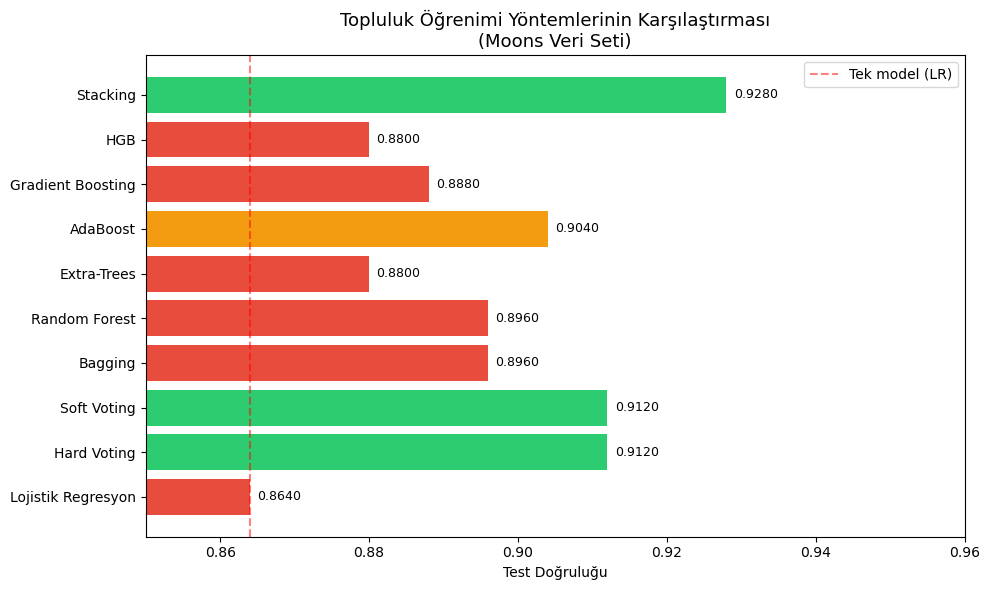

In [17]:
# Tüm yöntemlerin karşılaştırmalı özeti
import pandas as pd
import matplotlib.pyplot as plt

# Moons veri seti üzerinde tüm yöntemleri eğitelim ve karşılaştıralım
from sklearn.ensemble import (
    VotingClassifier, BaggingClassifier, RandomForestClassifier,
    ExtraTreesClassifier, AdaBoostClassifier, GradientBoostingClassifier,
    HistGradientBoostingClassifier, StackingClassifier
)

models = {
    "Lojistik Regresyon": LogisticRegression(random_state=42),
    "Hard Voting": VotingClassifier(estimators=[
        ('lr', LogisticRegression(random_state=42)),
        ('rf', RandomForestClassifier(random_state=42, n_estimators=50)),
        ('svc', SVC(random_state=42))
    ], voting='hard'),
    "Soft Voting": VotingClassifier(estimators=[
        ('lr', LogisticRegression(random_state=42)),
        ('rf', RandomForestClassifier(random_state=42, n_estimators=50)),
        ('svc', SVC(probability=True, random_state=42))
    ], voting='soft'),
    "Bagging": BaggingClassifier(DecisionTreeClassifier(), n_estimators=100,
                                  n_jobs=-1, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42),
    "Extra-Trees": ExtraTreesClassifier(n_estimators=100, n_jobs=-1, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=50, random_state=42, algorithm="SAMME"),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "HGB": HistGradientBoostingClassifier(random_state=42),
    "Stacking": StackingClassifier(estimators=[
        ('lr', LogisticRegression(random_state=42)),
        ('rf', RandomForestClassifier(n_estimators=50, random_state=42)),
        ('svc', SVC(probability=True, random_state=42))
    ], cv=5, final_estimator=RandomForestClassifier(n_estimators=50, random_state=43))
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    results[name] = score
    print(f"{name:25s}: {score:.4f}")

# Görselleştirme
fig, ax = plt.subplots(figsize=(10, 6))
names = list(results.keys())
scores = list(results.values())
colors = ['#e74c3c' if s < 0.9 else '#f39c12' if s < 0.91 else '#2ecc71' for s in scores]
bars = ax.barh(names, scores, color=colors)
ax.set_xlim(0.85, 0.96)
ax.set_xlabel('Test Doğruluğu')
ax.set_title('Topluluk Öğrenimi Yöntemlerinin Karşılaştırması\n(Moons Veri Seti)', fontsize=13)
for bar, val in zip(bars, scores):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.axvline(x=scores[0], color='red', linestyle='--', alpha=0.5, label='Tek model (LR)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 1. Kurulum <a id='kurulum'></a>


### Python Versiyon Kontrolü

Bu proje **Python 3.10 veya üzeri** gerektirir. `assert` ifadesi, koşul sağlanmazsa hata fırlatır ve çalışmayı durdurur. Bu sayede uyumsuz bir Python sürümüyle yanlışlıkla çalışmayı engelleriz.

In [2]:
import sys

# sys.version_info: Python'un versiyon bilgisini tuple olarak döner, ör. (3, 11, 0)
# >= (3,10) → Python 3.10 veya daha yeni bir sürüm gerektirir
# Koşul sağlanmazsa AssertionError fırlatılır
assert sys.version_info >= (3, 10), "Python 3.10 veya üzeri gereklidir!"

print(f"✅ Python versiyonu: {sys.version}")

✅ Python versiyonu: 3.10.18 (main, Jun  5 2025, 08:13:51) [Clang 14.0.6 ]


### Scikit-Learn Versiyon Kontrolü

Bu notebook **Scikit-Learn 1.6.1 veya üzeri** gerektirir. `packaging.version.Version` sınıfı, versiyon dizelerini karşılaştırmak için kullanılır (string karşılaştırması `'1.10' < '1.6'` gibi yanlış sonuçlar verebileceğinden).

In [3]:
from packaging.version import Version
import sklearn

# sklearn.__version__: Scikit-Learn'in yüklü versiyonunu string olarak döner
# Version() sınıfı, versiyon stringlerini doğru biçimde karşılaştırır
assert Version(sklearn.__version__) >= Version("1.6.1"), "Scikit-Learn 1.6.1+ gereklidir!"

print(f"✅ Scikit-Learn versiyonu: {sklearn.__version__}")

ModuleNotFoundError: No module named 'sklearn'

### Grafik Ayarları

`plt.rc()` fonksiyonu, Matplotlib'in global (varsayılan) parametrelerini ayarlar. Bu ayarlar tüm notebook boyunca geçerli olur ve her grafikte ayrı ayrı stil belirtmek zorunda kalmayız.

In [30]:
import matplotlib.pyplot as plt

# Tüm grafiklerde kullanılacak genel yazı tipi boyutu
plt.rc('font', size=14)

# Eksen etiketleri ve başlık boyutları
plt.rc('axes', labelsize=14, titlesize=14)

# Lejant (legend) boyutu
plt.rc('legend', fontsize=14)

# X ve Y ekseni üzerindeki sayıların boyutu
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

print("✅ Grafik ayarları yapıldı.")

✅ Grafik ayarları yapıldı.


---
## 2. Oylama Sınıflandırıcıları (Voting Classifiers) <a id='oylama'></a>

**Temel Fikir:** Yanlı (taraflı) bir paranın tura ihtimali %51 olsun. Ne kadar çok atarsak, çoğunlukla tura çıkma olasılığı o kadar artar. Bunu **Büyük Sayılar Yasası** garantiler. Aşağıdaki grafik bunu göstermektedir.

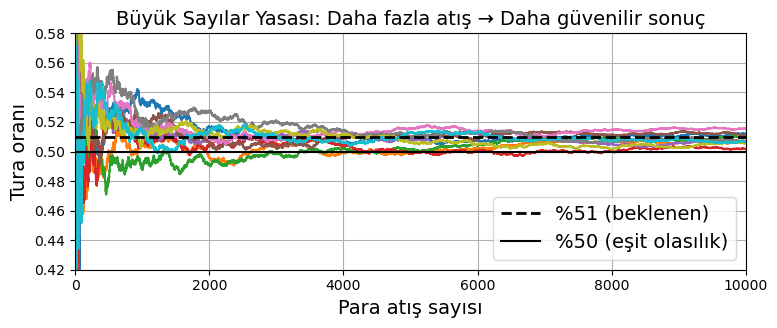

In [31]:
# ═══════════════════════════════════════════════════════════════
# BÜYÜK SAYILAR YASASI GÖRSELİ (Şekil 6-3'e karşılık gelir)
# ═══════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import numpy as np

# ── Para Simülasyonu ──
heads_proba = 0.51  # Turanın olasılığı %51 (hafifçe yanlı)

# Tekrar üretilebilir rastgele sayı üreteci (seed=42 → aynı sonuçlar)
rng = np.random.default_rng(seed=42)

# 10.000 satır × 10 sütun: 10 ayrı serinin her biri 10.000 atışı
# rng.random() → [0,1) aralığında uniform sayılar
# < heads_proba → True/False, astype(int32) → 1=tura, 0=yazı
coin_tosses = (rng.random((10000, 10)) < heads_proba).astype(np.int32)

# cumsum(axis=0): her satırda o ana kadarki birikimli tura sayısı
cumulative_heads = coin_tosses.cumsum(axis=0)

# reshape(-1,1): atış sayısını sütuna çevir → yayın (broadcasting) ile böl
# Sonuç: her atıştan sonra tura oranı
cumulative_heads_ratio = cumulative_heads / np.arange(1, 10001).reshape(-1, 1)

# ── Grafik ──
plt.figure(figsize=(8, 3.5))

# 10 serinin tüm tura oranlarını çiz
plt.plot(cumulative_heads_ratio)

# Beklenen değer: %51 kesikli çizgi
plt.plot([0, 10000], [0.51, 0.51], "k--", linewidth=2, label="%51 (beklenen)")

# Eşit olasılık: %50 düz çizgi
plt.plot([0, 10000], [0.5, 0.5], "k-", label="%50 (eşit olasılık)")

plt.xlabel("Para atış sayısı")
plt.ylabel("Tura oranı")
plt.title("Büyük Sayılar Yasası: Daha fazla atış → Daha güvenilir sonuç")
plt.legend(loc="lower right")
plt.axis([0, 10000, 0.42, 0.58])
plt.grid()
plt.tight_layout()
plt.show()

# ══ YORUM ══
# Başlangıçta seriler dağınık görünür, ancak atış sayısı arttıkça
# tüm seriler %51 çizgisine yakınsar ve %50'nin üzerinde kalır.
# Topluluk öğrenimindeki mantık da aynıdır: yeterince çok ve
# birbirinden bağımsız tahminleyici, küçük avantajları büyütür.

### Hard Voting (Sert Oylama) Sınıflandırıcısı

Her sınıflandırıcının tahminini al, **en çok oy alan sınıfı** seç. Çeşitli algoritmalar birleştirildiğinde genellikle her birinden daha iyi sonuç verir.

In [32]:
# ═══════════════════════════════════════════════════════════════
# OYLAMA SINIFLANDIRICI KURULUMU
# ═══════════════════════════════════════════════════════════════

from sklearn.datasets import make_moons
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# ── Veri Seti: make_moons ──
# İki yarım ay şeklinde, birbirine karışmış iki sınıf
# n_samples=500: toplam 500 örnek
# noise=0.30: Gauss gürültüsü ekler → sınıflar daha az net ayrılır
# random_state=42: sonuçları tekrar üretilebilir yapar
X, y = make_moons(n_samples=500, noise=0.30, random_state=42)

# Eğitim (%75) / Test (%25) bölmesi → 375 eğitim, 125 test örneği
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# ── VotingClassifier Oluşturma ──
# estimators: (isim, model) çiftlerinden oluşan liste
# Üç farklı algoritma kullanıyoruz → her biri farklı türde hatalar yapar
voting_clf = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(random_state=42)),      # Doğrusal model
        ('rf', RandomForestClassifier(random_state=42)),  # Ağaç tabanlı
        ('svc', SVC(random_state=42))                     # Kernel tabanlı
    ]
    # voting='hard' varsayılandır → çoğunluk oyu
)

# fit() → her sınıflandırıcının kopyasını alır ve eğitir
voting_clf.fit(X_train, y_train)

print("✅ VotingClassifier (hard voting) eğitildi.")
print(f"   Eğitim seti boyutu: {X_train.shape}")
print(f"   Test seti boyutu  : {X_test.shape}")

✅ VotingClassifier (hard voting) eğitildi.
   Eğitim seti boyutu: (375, 2)
   Test seti boyutu  : (125, 2)


In [33]:
# ═══════════════════════════════════════════════════════════════
# BİREYSEL SINIFLANDIRICI DOĞRULUKLARI
# ═══════════════════════════════════════════════════════════════

# named_estimators_: eğitilmiş modellere isimle erişim sağlar
# .items() → (isim, model) çiftleri
print("Bireysel Sınıflandırıcı Doğrulukları:")
print("-" * 35)
for name, clf in voting_clf.named_estimators_.items():
    score = clf.score(X_test, y_test)  # test setinde doğruluk
    print(f"  {name:5s} = {score:.3f}  ({score*100:.1f}%)")

# Beklenen çıktı:
# lr  = 0.864  (86.4%)   ← Lojistik Regresyon
# rf  = 0.896  (89.6%)   ← Rastgele Orman
# svc = 0.896  (89.6%)   ← Destek Vektör Makinesi

Bireysel Sınıflandırıcı Doğrulukları:
-----------------------------------
  lr    = 0.864  (86.4%)
  rf    = 0.896  (89.6%)
  svc   = 0.896  (89.6%)


In [34]:
# ═══════════════════════════════════════════════════════════════
# HARD VOTING: İLK TEST ÖRNEĞİ İÇİN TAHMİN
# ═══════════════════════════════════════════════════════════════

# Topluluğun tahmini (çoğunluk oyu)
topluluk_tahmini = voting_clf.predict(X_test[:1])
print(f"Topluluğun tahmini       : {topluluk_tahmini}")

# Her bireysel modelin tahmini
# estimators_: eğitilmiş modellerin listesi
bireysel_tahminler = [clf.predict(X_test[:1]) for clf in voting_clf.estimators_]
print(f"Bireysel tahminler [lr, rf, svc]: {bireysel_tahminler}")

# YORUM:
# lr=1, rf=1, svc=0 → 2 oy sınıf-1, 1 oy sınıf-0
# Çoğunluk: sınıf-1 → topluluk sınıf-1 tahmin eder

Topluluğun tahmini       : [1]
Bireysel tahminler [lr, rf, svc]: [array([1]), array([1]), array([0])]


In [35]:
# ═══════════════════════════════════════════════════════════════
# HARD VOTING: GENEL TEST DOĞRULUĞU
# ═══════════════════════════════════════════════════════════════

hard_score = voting_clf.score(X_test, y_test)
print(f"Hard Voting Classifier doğruluğu: {hard_score:.3f} ({hard_score*100:.1f}%)")

# Beklenen: 0.912 (%91.2)
# En iyi bireysel model %89.6 iken topluluk %91.2 elde etti!
# → Farklı türde hata yapan modeller bir araya gelince tüm hataları telafi eder.

Hard Voting Classifier doğruluğu: 0.912 (91.2%)


### Soft Voting (Yumuşak Oylama)

Her model bir sınıf için **olasılık** tahmini yapıyorsa, bu olasılıklar ortalaması alınarak en yüksek ortalama olasılığa sahip sınıf seçilir. **Güvenli oyları daha fazla ağırlıklandırır** → genellikle hard voting'den daha iyi sonuç verir.

> ⚠️ `SVC` varsayılan olarak olasılık tahmin etmez. `probability=True` parametresiyle etkinleştirilmelidir (bu, çapraz doğrulama kullanarak olasılıkları tahmin eder ve eğitimi yavaşlatır).

In [36]:
# ═══════════════════════════════════════════════════════════════
# SOFT VOTING (YUMUŞAK OYLAMA)
# ═══════════════════════════════════════════════════════════════

# Mevcut modeli hard→soft moduna geçirelim (yeniden oluşturmak gerekmez)
voting_clf.voting = "soft"

# SVC'nin olasılık tahmini etkinleştiriliyor
# Bu parametre yeniden eğitimden ÖNCE ayarlanmalı!
voting_clf.named_estimators["svc"].probability = True

# Yeniden eğit (SVC'nin probability=True ile yeniden eğitilmesi gerekiyor)
voting_clf.fit(X_train, y_train)

soft_score = voting_clf.score(X_test, y_test)
print(f"Soft Voting Classifier doğruluğu: {soft_score:.3f} ({soft_score*100:.1f}%)")

# Beklenen: 0.920 (%92.0)
# Hard voting (%91.2) → Soft voting (%92.0) → iyileşme!

print("\n📊 Karşılaştırma:")
print(f"   Bireysel en iyi (RF/SVC) : %89.6")
print(f"   Hard Voting              : %{hard_score*100:.1f}")
print(f"   Soft Voting              : %{soft_score*100:.1f}")

Soft Voting Classifier doğruluğu: 0.920 (92.0%)

📊 Karşılaştırma:
   Bireysel en iyi (RF/SVC) : %89.6
   Hard Voting              : %91.2
   Soft Voting              : %92.0


---
## 3. Bagging ve Pasting <a id='bagging'></a>

**Fikir:** Aynı algoritmayı eğitim setinin **farklı rastgele alt kümelerinde** defalarca eğit.

| Yöntem | Örnekleme | Açıklama |
|--------|-----------|----------|
| **Bagging** | Yerine koyarak (bootstrap) | Aynı örnek birden fazla kez seçilebilir |
| **Pasting** | Yerine koymadan | Her örnek en fazla bir kez seçilir |

Her bireysel tahminleyici daha yüksek **yanlılıkla (bias)** çalışır, ancak birleştirme hem yanlılığı hem de **varyansı** düşürür.

In [41]:
# ═══════════════════════════════════════════════════════════════
# BAGGING SINIFLANDIRICI
# ═══════════════════════════════════════════════════════════════

from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

# BaggingClassifier Parametreleri:
# ─ 1. arg : Temel tahminleyici (base estimator) → Karar Ağacı
# ─ n_estimators=500 : 500 ayrı karar ağacı eğitilecek
# ─ max_samples=100  : Her ağaç, eğitim setinden 100 örnek kullanır
#                      (varsayılan bootstrap=True → yerine koyarak örnekleme)
# ─ n_jobs=None        : Tüm CPU çekirdeklerini kullan (paralel eğitim)
# ─ random_state=42  : Tekrar üretilebilirlik
#
# bootstrap=False yaparsanız → Pasting (yerine koymadan örnekleme)

bag_clf = BaggingClassifier(
    DecisionTreeClassifier(),
    n_estimators=500,
    max_samples=100,
    n_jobs=None,
    random_state=42
)
bag_clf.fit(X_train, y_train)

print("✅ BaggingClassifier eğitildi.")


print(f"   500 ayrı karar ağacı, her biri 100 rastgele örnekle eğitildi.")
print(f"   BaggingClassifier doğruluğu: {bag_clf.score(X_test, y_test):.3f}")

✅ BaggingClassifier eğitildi.
   500 ayrı karar ağacı, her biri 100 rastgele örnekle eğitildi.
   BaggingClassifier doğruluğu: 0.904


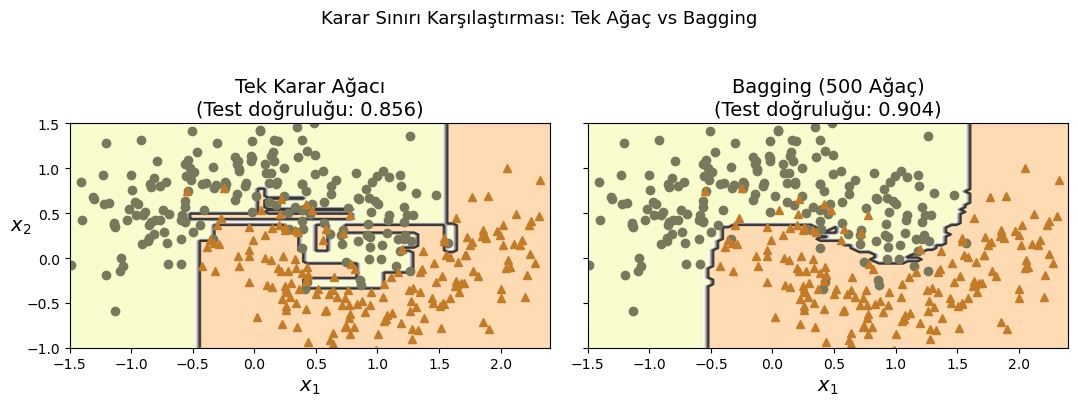

In [42]:
# ═══════════════════════════════════════════════════════════════
# KARAR SINIRI GÖRSELLEŞTİRME: TEK AĞAÇ vs BAGGING
# ═══════════════════════════════════════════════════════════════

def plot_decision_boundary(clf, X, y, alpha=1.0):
    """Bir sınıflandırıcının karar sınırını 2B uzayda çizer."""
    axes = [-1.5, 2.4, -1, 1.5]

    # meshgrid: tüm (x1, x2) koordinat kombinasyonlarını oluşturur
    x1, x2 = np.meshgrid(
        np.linspace(axes[0], axes[1], 100),  # x ekseni: 100 nokta
        np.linspace(axes[2], axes[3], 100)   # y ekseni: 100 nokta
    )

    # Her nokta için tahmin al → 10000 noktalık ızgara
    X_new = np.c_[x1.ravel(), x2.ravel()]   # (10000, 2) matris
    y_pred = clf.predict(X_new).reshape(x1.shape)  # (100, 100) matrise geri şekillendir

    # Karar bölgelerini renklendir
    plt.contourf(x1, x2, y_pred, alpha=0.3 * alpha, cmap='Wistia')
    # Karar sınırını çiz
    plt.contour(x1, x2, y_pred, cmap="Greys", alpha=0.8 * alpha)

    # Eğitim örneklerini nokta olarak çiz
    colors = ["#78785c", "#c47b27"]
    markers = ("o", "^")
    for idx in (0, 1):
        plt.plot(X[:, 0][y == idx], X[:, 1][y == idx],
                 color=colors[idx], marker=markers[idx], linestyle="none")
    plt.axis(axes)
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$", rotation=0)

# Tek karar ağacı eğit (karşılaştırma için)
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)

fig, axes = plt.subplots(ncols=2, figsize=(11, 4), sharey=True)

# Sol: Tek karar ağacı
plt.sca(axes[0])
plot_decision_boundary(tree_clf, X_train, y_train)
plt.title(f"Tek Karar Ağacı\n(Test doğruluğu: {tree_clf.score(X_test,y_test):.3f})")

# Sağ: Bagging topluluğu
plt.sca(axes[1])
plot_decision_boundary(bag_clf, X_train, y_train)
plt.title(f"Bagging (500 Ağaç)\n(Test doğruluğu: {bag_clf.score(X_test,y_test):.3f})")
plt.ylabel("")

plt.suptitle("Karar Sınırı Karşılaştırması: Tek Ağaç vs Bagging", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

# YORUM:
# Tek ağaç: karar sınırı pürüzlü, düzensiz → yüksek varyans (aşırı öğrenme)
# Bagging : karar sınırı daha düzgün, genelleşme daha iyi → düşük varyans

### Out-of-Bag (OOB) Değerlendirmesi

Bagging'de her tahminleyici için eğitim örneklerinin yaklaşık **%37'si hiç seçilmez** (torba dışı = out-of-bag). Bu örnekler, **ayrı bir doğrulama seti olmaksızın** modeli değerlendirmek için kullanılabilir.

In [44]:
# ═══════════════════════════════════════════════════════════════
# OOB (TORBA DIŞI) DEĞERLENDİRMESİ
# ═══════════════════════════════════════════════════════════════

# oob_score=True → eğitim sonrası otomatik OOB değerlendirmesi yap
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(),
    n_estimators=500,
    oob_score=True,   # ← Bu parametre OOB değerlendirmesini açar
    n_jobs=None,
    random_state=42
)
bag_clf.fit(X_train, y_train)

# oob_score_: OOB örnekleri üzerindeki doğruluk tahmini
# Ayrı bir doğrulama seti kullanmaksızın elde edilir!
print(f"OOB Skoru (tahmin edilen doğruluk): {bag_clf.oob_score_:.3f}")
# Beklenen: 0.896 → model yaklaşık %89.6 test doğruluğuna sahip diye öngörülüyor

OOB Skoru (tahmin edilen doğruluk): 0.896


In [45]:
# ═══════════════════════════════════════════════════════════════
# OOB KARAR FONKSİYONU: SINIF OLASILIKLARINI GÖRME
# ═══════════════════════════════════════════════════════════════

# oob_decision_function_: her eğitim örneği için OOB tahminleyicilerin
# ürettiği sınıf olasılıkları (karar fonksiyonu)
# İlk 3 eğitim örneğinin olasılıklarını görelim
oob_proba = bag_clf.oob_decision_function_[:3]
print("İlk 3 eğitim örneği için OOB sınıf olasılıkları:")
print("  [Sınıf-0 olasılığı, Sınıf-1 olasılığı]")
for i, proba in enumerate(oob_proba):
    print(f"  Örnek {i+1}: [{proba[0]:.4f}, {proba[1]:.4f}] → Tahmin: Sınıf-{proba.argmax()}")

# Beklenen:
# [[0.3235, 0.6765],  → %67.6 ihtimalle Sınıf-1
#  [0.3375, 0.6625],  → %66.3 ihtimalle Sınıf-1
#  [1.0,   0.0   ]]   → %100 ihtimalle Sınıf-0

İlk 3 eğitim örneği için OOB sınıf olasılıkları:
  [Sınıf-0 olasılığı, Sınıf-1 olasılığı]
  Örnek 1: [0.3235, 0.6765] → Tahmin: Sınıf-1
  Örnek 2: [0.3375, 0.6625] → Tahmin: Sınıf-1
  Örnek 3: [1.0000, 0.0000] → Tahmin: Sınıf-0


In [46]:
# ═══════════════════════════════════════════════════════════════
# OOB TAHMİNİNİ GERÇEK TEST DOĞRULUĞUYLA KARŞILAŞTIRMA
# ═══════════════════════════════════════════════════════════════

from sklearn.metrics import accuracy_score

# Gerçek test tahminleri
y_pred = bag_clf.predict(X_test)
test_score = accuracy_score(y_test, y_pred)

print(f"OOB Skoru (tahmini)    : {bag_clf.oob_score_:.3f}")
print(f"Gerçek Test Doğruluğu  : {test_score:.3f}")
print(f"Fark                   : {abs(bag_clf.oob_score_ - test_score):.3f}")

# Beklenen: OOB=0.896, Test=0.912
# OOB biraz kötümser bir tahmin yaptı ama makul derecede yakın!
# Ayrı bir doğrulama seti gerekmediği için eğitim için daha fazla veri kalır.

OOB Skoru (tahmini)    : 0.896
Gerçek Test Doğruluğu  : 0.920
Fark                   : 0.024


In [47]:
# ═══════════════════════════════════════════════════════════════
# %63 ÖRNEKLEME ORANININ MATEMATİKSEL AÇIKLAMASI
# ═══════════════════════════════════════════════════════════════

# Yerine koyarak m örnek seçerken, herhangi bir örneğin HİÇ seçilmeme olasılığı:
#   (1 - 1/m)^m   →   m → ∞  iken   e^(-1) ≈ 0.368
#
# Yani yaklaşık %36.8 seçilmez (OOB) → yaklaşık %63.2 seçilir

m = 1000  # örnek büyük m değeri
oran_1 = 1 - (1 - 1 / m) ** m
oran_2 = 1 - np.exp(-1)  # Matematiksel limit

print("Bootstrap Örnekleme — Seçilme Oranı Hesabı:")
print(f"  m={m} için hesaplama : {oran_1:.4f} (%{oran_1*100:.1f})")
print(f"  Matematiksel limit (1-e⁻¹): {oran_2:.4f} (%{oran_2*100:.1f})")
print(f"\n→ Her bootstrap örnekleminde yaklaşık %63'ü seçilir, %37'si OOB kalır.")

Bootstrap Örnekleme — Seçilme Oranı Hesabı:
  m=1000 için hesaplama : 0.6323 (%63.2)
  Matematiksel limit (1-e⁻¹): 0.6321 (%63.2)

→ Her bootstrap örnekleminde yaklaşık %63'ü seçilir, %37'si OOB kalır.


---
## 4. Rastgele Ormanlar (Random Forests) <a id='random-forest'></a>

Rastgele Orman = Bagging + Karar Ağaçları + **Ekstra Rastgelelik**

Her düğümde tüm özelliklerin en iyisi yerine **rastgele seçilen bir özellik alt kümesindeki en iyi** bölünme kullanılır. Bu, ağaçları birbirinden daha bağımsız kılar ve **varyansı düşürür**.

In [48]:
# ═══════════════════════════════════════════════════════════════
# RASTGELE ORMAN SINIFLANDIRICI
# ═══════════════════════════════════════════════════════════════

from sklearn.ensemble import RandomForestClassifier

# RandomForestClassifier Parametreleri:
# ─ n_estimators=500  : 500 karar ağacı
# ─ max_leaf_nodes=16 : Her ağaç en fazla 16 yaprak düğümüne sahip olabilir
#                       (budama → aşırı öğrenmeyi önler)
# ─ n_jobs=1         : Tüm CPU çekirdeklerini kullan
# İç mekanizma: Her düğümde √n özellik rastgele seçilip en iyi bölünme bulunur

rnd_clf = RandomForestClassifier(
    n_estimators=500,
    max_leaf_nodes=16,
    n_jobs=1,
    random_state=42
)
rnd_clf.fit(X_train, y_train)
y_pred_rf = rnd_clf.predict(X_test)

rf_score = accuracy_score(y_test, y_pred_rf)
print(f"✅ Rastgele Orman eğitildi.")
print(f"   Test doğruluğu: {rf_score:.3f} (%{rf_score*100:.1f})")

✅ Rastgele Orman eğitildi.
   Test doğruluğu: 0.912 (%91.2)


### Rastgele Orman = BaggingClassifier ile Eşdeğerdir

Aşağıdaki `BaggingClassifier`, yukarıdaki `RandomForestClassifier` ile **aynı tahminleri üretir**. Yalnızca `max_features="sqrt"` (karekök kadar özellik seçimi) ve `max_leaf_nodes=16` eklenmiştir.

In [50]:
# ═══════════════════════════════════════════════════════════════
# RASTGELE ORMAN = BAGGINGCLASSİFİER EŞDEĞERLİĞİ
# ═══════════════════════════════════════════════════════════════

# Bu BaggingClassifier, yukarıdaki RandomForestClassifier ile özdeş davranır:
# max_features="sqrt" → Her düğümde √n özellik kullanılır (RF'nin farkı bu!)
# max_leaf_nodes=16   → Budama limiti
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(max_features="sqrt", max_leaf_nodes=16),
    n_estimators=500,
    n_jobs=1,
    random_state=42
)
bag_clf.fit(X_train, y_train)
y_pred_bag = bag_clf.predict(X_test)

# Tahminlerin birebir aynı olup olmadığını doğrula
esit_mi = np.all(y_pred_bag == y_pred_rf)
print(f"RandomForestClassifier ve eşdeğer BaggingClassifier tahminleri aynı mı? → {esit_mi}")
print("✅ İspat: RandomForest, optimize edilmiş bir Bagging+Karar Ağacı topluluğudur.")

RandomForestClassifier ve eşdeğer BaggingClassifier tahminleri aynı mı? → True
✅ İspat: RandomForest, optimize edilmiş bir Bagging+Karar Ağacı topluluğudur.


### Özellik Önemi (Feature Importance)

Rastgele Ormanların güçlü bir özelliği: hangi özelliklerin tahminler için **ne kadar önemli** olduğunu otomatik hesaplar. Her özelliğin, ormandaki tüm düğümlerde **safsızlığı (impurity) ortalama ne kadar azalttığına** bakılır.

🌸 Iris Veri Seti — Özellik Önemleri:
--------------------------------------------------
  sepal length (cm)        : 0.11 (%11.2)
  sepal width (cm)         : 0.02 (%2.3)
  petal length (cm)        : 0.44 (%44.1)
  petal width (cm)         : 0.42 (%42.3)

Kontrol: Önem skorları toplamı = 1.0000


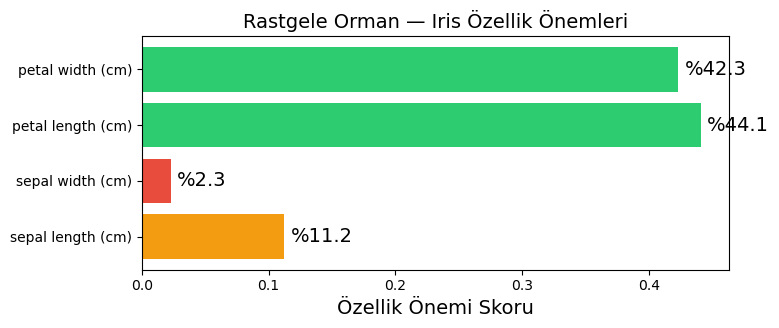

In [52]:
# ═══════════════════════════════════════════════════════════════
# ÖZELLİK ÖNEMİ — IRIS VERİ SETİ
# ═══════════════════════════════════════════════════════════════

from sklearn.datasets import load_iris

# Iris veri seti: 4 özellik (çiçek ölçüleri), 3 sınıf
iris = load_iris(as_frame=True)

rnd_clf = RandomForestClassifier(n_estimators=500, random_state=42)
rnd_clf.fit(iris.data, iris.target)

# feature_importances_: her özelliğin önem skoru
# (tüm önemlerin toplamı = 1.0)
print("🌸 Iris Veri Seti — Özellik Önemleri:")
print("-" * 50)
importances = []
for score, name in zip(rnd_clf.feature_importances_, iris.data.columns):
    print(f"  {name:25s}: {score:.2f} (%{score*100:.1f})")
    importances.append((score, name))

# Beklenen:
# sepal length (cm): 0.11 (%11) ← görece önemsiz
# sepal width  (cm): 0.02 (%2)  ← en az önemli
# petal length (cm): 0.44 (%44) ← en önemli!
# petal width  (cm): 0.42 (%42) ← ikinci en önemli

print(f"\nKontrol: Önem skorları toplamı = {rnd_clf.feature_importances_.sum():.4f}")

# Görselleştirme
fig, ax = plt.subplots(figsize=(8, 3.5))
scores = rnd_clf.feature_importances_
names = iris.data.columns
renkler = ['#e74c3c' if s < 0.1 else '#f39c12' if s < 0.2 else '#2ecc71' for s in scores]
bars = ax.barh(names, scores, color=renkler)
ax.set_xlabel('Özellik Önemi Skoru')
ax.set_title('Rastgele Orman — Iris Özellik Önemleri')
for bar, val in zip(bars, scores):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'%{val*100:.1f}', va='center')
plt.tight_layout()
plt.show()

MNIST veri seti yükleniyor (bu biraz sürebilir)...
Rastgele Orman eğitiliyor...


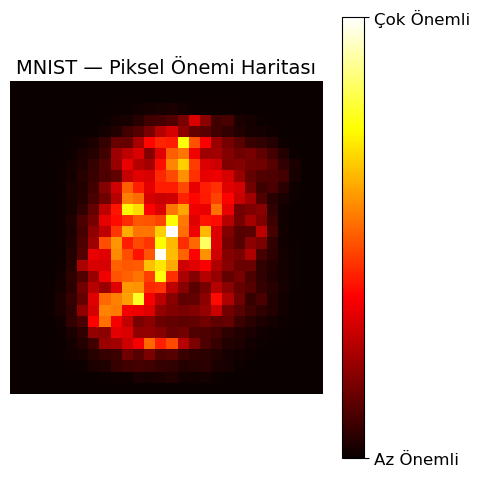

In [54]:
# ═══════════════════════════════════════════════════════════════
# ÖZELLİK ÖNEMİ — MNIST PİKSEL HARİTASI (Şekil 6-6)
# ═══════════════════════════════════════════════════════════════

from sklearn.datasets import fetch_openml

print("MNIST veri seti yükleniyor (bu biraz sürebilir)...")
# MNIST: 70.000 el yazısı rakam görüntüsü, her biri 28×28=784 piksel
X_mnist, y_mnist = fetch_openml('mnist_784', return_X_y=True, as_frame=False)

# 100 ağaçlık Rastgele Orman eğit
print("Rastgele Orman eğitiliyor...")
rnd_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rnd_clf.fit(X_mnist, y_mnist)

# feature_importances_: 784 pikselin her birinin önem skoru
# reshape(28, 28): 784 boyutlu vektörü 28×28 görüntüye çevir
heatmap_image = rnd_clf.feature_importances_.reshape(28, 28)

plt.figure(figsize=(5, 5))
plt.imshow(heatmap_image, cmap="hot")  # Sıcak renk haritası: açık=önemli, koyu=önemsiz
cbar = plt.colorbar(ticks=[rnd_clf.feature_importances_.min(),
                           rnd_clf.feature_importances_.max()])
cbar.ax.set_yticklabels(['Az Önemli', 'Çok Önemli'], fontsize=12)
plt.title("MNIST — Piksel Önemi Haritası")
plt.axis("off")
plt.tight_layout()
plt.show()

# YORUM:
# Merkezdeki pikseller (rakamların yazıldığı bölge) daha önemli
# Kenar pikseller (genellikle boş olan bölge) daha az önemli
# Bu bilgi özellik seçimi için kullanılabilir!

---
## 5. Boosting — AdaBoost (Uyarlamalı Güçlendirme) <a id='adaboost'></a>

**Fikir:** Tahminleyicileri **sıralı** eğit. Her yeni model, öncekinin **yanlış sınıflandırdığı örneklere** daha fazla dikkat et.

**Algoritma özeti:**
1. Her örneğin başlangıç ağırlığı = 1/m (eşit)
2. İlk model eğitilir → hatalı örneklerin ağırlıkları **artırılır**
3. Yeni model artırılmış ağırlıklarla eğitilir
4. Döngü istenilen sayıda tekrarlanır
5. Tahmin: tüm modellerin **ağırlıklı** çoğunluk oyu

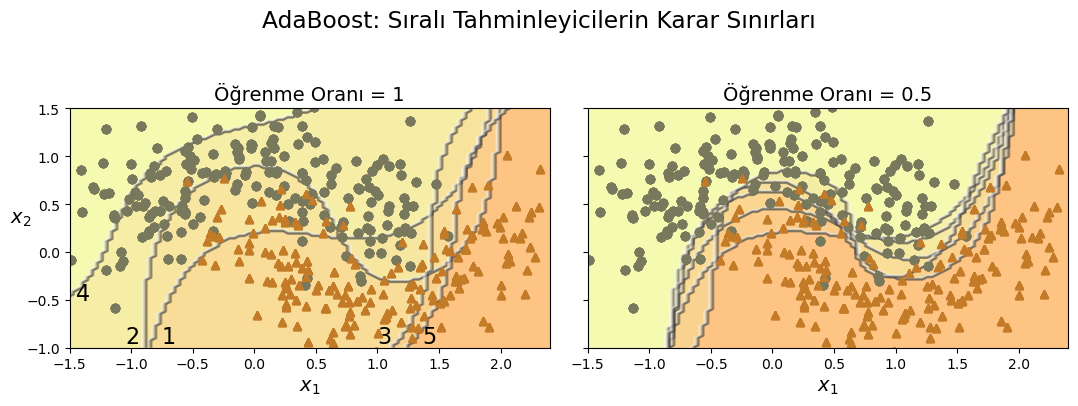

In [69]:
# ═══════════════════════════════════════════════════════════════
# ADABOOST ALGORİTMASI — GÖRSEL (Şekil 6-8)
# ═══════════════════════════════════════════════════════════════
# Farklı öğrenme oranlarıyla 5 sıralı SVM sınıflandırıcının
# karar sınırlarının nasıl değiştiğini görselleştirir

m = len(X_train)  # Eğitim örneği sayısı

fig, axes = plt.subplots(ncols=2, figsize=(11, 4), sharey=True)

for subplot, learning_rate in ((0, 1), (1, 0.5)):
    # Başlangıç: tüm örnekler eşit ağırlıklı (1/m)
    sample_weights = np.ones(m) / m
    plt.sca(axes[subplot])

    for i in range(5):  # 5 ardışık sınıflandırıcı
        # ── Model Eğitimi ──
        # sample_weight: her örneğin eğitimdeki ağırlığı
        svm_clf = SVC(C=0.2, gamma=0.6, random_state=42)
        svm_clf.fit(X_train, y_train, sample_weight=sample_weights * m)
        y_pred = svm_clf.predict(X_train)

        # ── Ağırlıklı Hata Oranı Hesabı (Denklem 6-1) ──
        # Yanlış tahmin edilen örneklerin ağırlıkları toplamı
        error_weights = sample_weights[y_pred != y_train].sum()
        r = error_weights / sample_weights.sum()  # Normalize edilmiş hata

        # ── Tahminleyici Ağırlığı (Denklem 6-2) ──
        # r küçük (iyi model) → α büyük
        # r büyük (kötü model) → α küçük veya negatif
        alpha = learning_rate * np.log((1 - r) / r)

        # ── Örnek Ağırlıklarını Güncelle (Denklem 6-3) ──
        # Yanlış tahmin edilen örneklerin ağırlığı exp(α) ile çarpılır
        sample_weights[y_pred != y_train] *= np.exp(alpha)

        # ── Normalizasyon ──
        # Tüm ağırlıkların toplamı tekrar 1'e eşit olsun
        sample_weights /= sample_weights.sum()

        # Karar sınırını çiz
        plot_decision_boundary(svm_clf, X_train, y_train, alpha=0.4)
        plt.title(f"Öğrenme Oranı = {learning_rate}")

    if subplot == 0:
        # Ardışık tahminleyici numaraları
        # 'pos' ilk sayı, 'y_coord' ikinci sayı, 'num' ise tırnak içindeki string olur.
               for pos, y_coord, num in [(-0.75,-0.95,'1'), (-1.05,-0.95,'2'), 
                          (1.0,-0.95,'3'), (-1.45,-0.5,'4'), (1.36,-0.95,'5')]:
                     plt.text(pos, y_coord,
                              num if len(num)==1 else num[2], fontsize=16)
    else:
        plt.ylabel("")

plt.suptitle("AdaBoost: Sıralı Tahminleyicilerin Karar Sınırları", y=1.02)
plt.tight_layout()
plt.show()

# YORUM:
# Her iterasyonda yanlış sınıflandırılan örnekler daha fazla ağırlık kazanır
# Yeni tahminleyici bu örneklere daha fazla odaklanır
# Düşük öğrenme oranı → daha yavaş ama daha stabil öğrenme

In [56]:
# ═══════════════════════════════════════════════════════════════
# ADABOOST SINIFLANDIRICI — SCIKIT-LEARN
# ═══════════════════════════════════════════════════════════════

from sklearn.ensemble import AdaBoostClassifier

# AdaBoostClassifier Parametreleri:
# ─ DecisionTreeClassifier(max_depth=1): "Decision Stump" (Karar Güdüğü)
#   max_depth=1 → sadece 1 karar düğümü + 2 yaprak → en basit ağaç
#   AdaBoost'un varsayılan temel tahminleyicisidir
#
# ─ n_estimators=30    : 30 sıralı güdük eğitilir
# ─ learning_rate=0.5  : Her tahminleyicinin katkısını ölçekler
#                        Küçük değer → daha yavaş öğrenme ama genellikle daha stabil
#
# ─ algorithm="SAMME"  : Scikit-Learn'in çok sınıflı AdaBoost uygulaması
#                        (Stagewise Additive Modeling using Multiclass Exponential loss)
#                        2 sınıf için SAMME, standart AdaBoost ile aynıdır

ada_clf = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1),
    n_estimators=30,
    learning_rate=0.5,
    random_state=42,
    algorithm="SAMME"
)
ada_clf.fit(X_train, y_train)

ada_score = ada_clf.score(X_test, y_test)
print(f"✅ AdaBoost Classifier eğitildi.")
print(f"   Test doğruluğu: {ada_score:.3f} (%{ada_score*100:.1f})")
print(f"   30 Decision Stump sıralı olarak kullanıldı.")

# İPUCU: AdaBoost aşırı öğreniyorsa:
# → n_estimators'ı azalt
# → Temel tahminleyiciyi daha güçlü düzenleştir (max_depth=1 bırak)

✅ AdaBoost Classifier eğitildi.
   Test doğruluğu: 0.880 (%88.0)
   30 Decision Stump sıralı olarak kullanıldı.


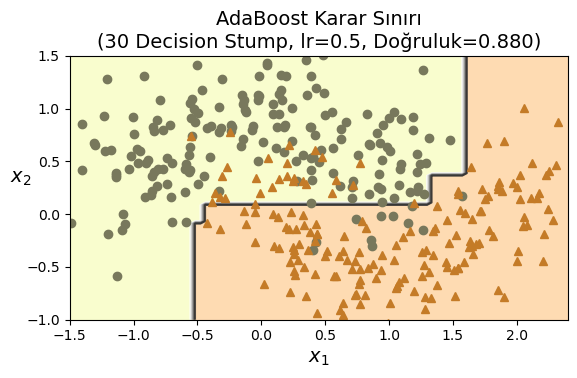

In [57]:
# ═══════════════════════════════════════════════════════════════
# ADABOOST KARAR SINIRI GÖRSELİ
# ═══════════════════════════════════════════════════════════════

plt.figure(figsize=(6, 4))
plot_decision_boundary(ada_clf, X_train, y_train)
plt.title(f"AdaBoost Karar Sınırı\n(30 Decision Stump, lr=0.5, Doğruluk={ada_score:.3f})")
plt.tight_layout()
plt.show()

# YORUM: AdaBoost'un karar sınırı bagging'den farklı görünür
# Zor örneklere odaklandığı için bazı bölgelerde daha hassas sınır çizer

---
## 6. Gradient Boosting (Gradyan Güçlendirme) <a id='gradient-boosting'></a>

**AdaBoost'tan farkı:** Örnek ağırlıklarını değiştirmek yerine, her yeni ağaç bir öncekinin **kalıntı hatalarına (residual errors)** uyar.

**Adım adım mantık:**
1. Ağaç-1: Ham veriye uyar → tahmin yap
2. Ağaç-2: (Gerçek - Tahmin-1) = Hata-1 → **hataya** uyar
3. Ağaç-3: (Hata-1 - Tahmin-2) = Hata-2 → **hatanın hatasına** uyar
4. **Toplam tahmin = Ağaç1 + Ağaç2 + Ağaç3 + ...**

In [58]:
# ═══════════════════════════════════════════════════════════════
# GRADIENT BOOSTING — MANUEL UYGULAMA
# ═══════════════════════════════════════════════════════════════

import numpy as np
from sklearn.tree import DecisionTreeRegressor

# ── Gürültülü İkinci Dereceden Veri Seti Oluştur ──
m = 100
rng = np.random.default_rng(seed=42)
X = rng.random((m, 1)) - 0.5   # [-0.5, 0.5] aralığında
noise = 0.05 * rng.standard_normal(m)  # Gauss gürültüsü
y = 3 * X[:, 0] ** 2 + noise   # Gerçek fonksiyon: y = 3x² + gürültü

# ── 1. Ağaç: Ham Veriye Uyar ──
# max_depth=2 → küçük ağaç, az varyans
tree_reg1 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg1.fit(X, y)
print("1. Ağaç eğitildi → ham y'ye uydu")

# ── 2. Ağaç: 1. Ağacın Kalıntı Hatalarına Uyar ──
y2 = y - tree_reg1.predict(X)   # Kalıntı hatalar = Gerçek - Tahmin_1
tree_reg2 = DecisionTreeRegressor(max_depth=2, random_state=43)
tree_reg2.fit(X, y2)             # y2 = hataları öğren
print("2. Ağaç eğitildi → 1. ağacın hatalarına uydu")

# ── 3. Ağaç: 2. Ağacın Kalıntı Hatalarına Uyar ──
y3 = y2 - tree_reg2.predict(X)  # Kalıntı hatalar = y2 - Tahmin_2
tree_reg3 = DecisionTreeRegressor(max_depth=2, random_state=44)
tree_reg3.fit(X, y3)             # y3 = hataların hatalarını öğren
print("3. Ağaç eğitildi → 2. ağacın hatalarına uydu")

# ── Tahmin: Tüm Ağaçların Toplamı ──
X_new = np.array([[-0.4], [0.], [0.5]])
# Her ağacın tahmini ayrı ayrı, toplamı nihai tahmin
tahmin1 = tree_reg1.predict(X_new)
tahmin2 = tree_reg2.predict(X_new)
tahmin3 = tree_reg3.predict(X_new)
toplam_tahmin = sum(tree.predict(X_new) for tree in (tree_reg1, tree_reg2, tree_reg3))

print("\nTahmin Dökümü:")
for xi, t1, t2, t3, top in zip(X_new.ravel(), tahmin1, tahmin2, tahmin3, toplam_tahmin):
    print(f"  x={xi:4.1f}: Ağaç1={t1:.3f} + Ağaç2={t2:.3f} + Ağaç3={t3:.3f} = {top:.3f}")

1. Ağaç eğitildi → ham y'ye uydu
2. Ağaç eğitildi → 1. ağacın hatalarına uydu
3. Ağaç eğitildi → 2. ağacın hatalarına uydu

Tahmin Dökümü:
  x=-0.4: Ağaç1=0.575 + Ağaç2=-0.013 + Ağaç3=0.012 = 0.574
  x= 0.0: Ağaç1=0.091 + Ağaç2=-0.013 + Ağaç3=-0.037 = 0.041
  x= 0.5: Ağaç1=0.444 + Ağaç2=0.272 + Ağaç3=-0.046 = 0.669


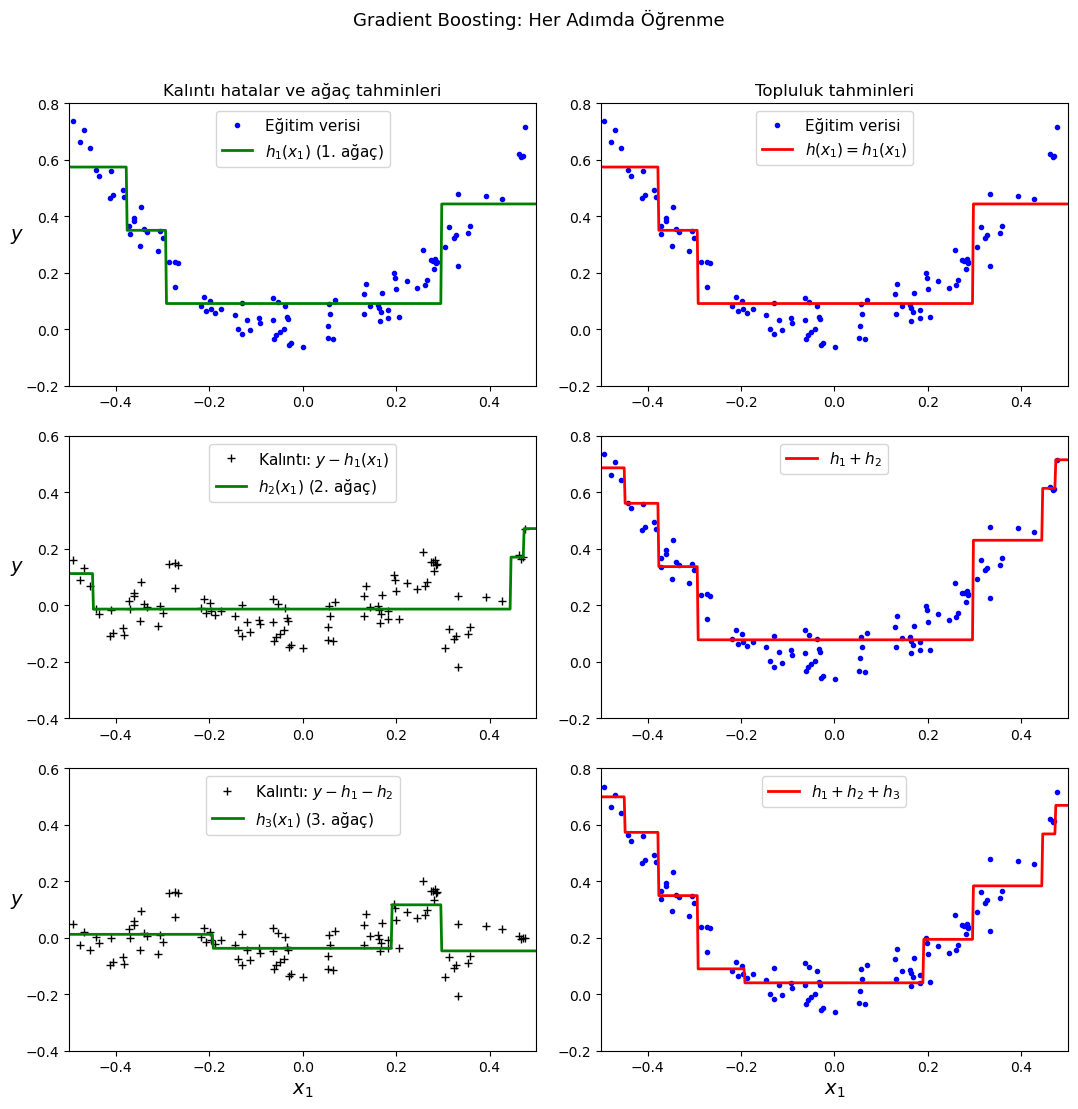

In [59]:
# ═══════════════════════════════════════════════════════════════
# GRADIENT BOOSTING GÖRSELLEŞTİRMESİ (Şekil 6-9)
# Her adımda kalıntı hatalar ve topluluk tahminleri
# ═══════════════════════════════════════════════════════════════

def plot_predictions(regressors, X, y, axes, style, label=None,
                     data_style="b.", data_label=None):
    """Regresörlerin toplu tahminini ve veriyi çizer."""
    x1 = np.linspace(axes[0], axes[1], 500)
    # Tüm regresörlerin tahminlerini topla (Gradient Boosting'in özü)
    y_pred = sum(reg.predict(x1.reshape(-1, 1)) for reg in regressors)
    plt.plot(X[:, 0], y, data_style, label=data_label)   # Veri noktaları
    plt.plot(x1, y_pred, style, linewidth=2, label=label) # Tahmin eğrisi
    if label or data_label:
        plt.legend(loc="upper center", fontsize=11)
    plt.axis(axes)

plt.figure(figsize=(11, 11))

# Sol sütun: her ağacın öğrendiği şey (kalıntı hatalar)
# Sağ sütun: topluluğun kümülatif tahmini

plt.subplot(3, 2, 1)
plot_predictions([tree_reg1], X, y, axes=[-0.5,0.5,-0.2,0.8],
                 style="g-", label="$h_1(x_1)$ (1. ağaç)", data_label="Eğitim verisi")
plt.ylabel("$y$  ", rotation=0)
plt.title("Kalıntı hatalar ve ağaç tahminleri", fontsize=12)

plt.subplot(3, 2, 2)
plot_predictions([tree_reg1], X, y, axes=[-0.5,0.5,-0.2,0.8],
                 style="r-", label="$h(x_1) = h_1(x_1)$", data_label="Eğitim verisi")
plt.title("Topluluk tahminleri", fontsize=12)

plt.subplot(3, 2, 3)
plot_predictions([tree_reg2], X, y2, axes=[-0.5,0.5,-0.4,0.6],
                 style="g-", label="$h_2(x_1)$ (2. ağaç)",
                 data_style="k+", data_label="Kalıntı: $y-h_1(x_1)$")
plt.ylabel("$y$  ", rotation=0)

plt.subplot(3, 2, 4)
plot_predictions([tree_reg1, tree_reg2], X, y, axes=[-0.5,0.5,-0.2,0.8],
                 style="r-", label="$h_1+h_2$")

plt.subplot(3, 2, 5)
plot_predictions([tree_reg3], X, y3, axes=[-0.5,0.5,-0.4,0.6],
                 style="g-", label="$h_3(x_1)$ (3. ağaç)",
                 data_style="k+", data_label="Kalıntı: $y-h_1-h_2$")
plt.xlabel("$x_1$")
plt.ylabel("$y$  ", rotation=0)

plt.subplot(3, 2, 6)
plot_predictions([tree_reg1, tree_reg2, tree_reg3], X, y,
                 axes=[-0.5,0.5,-0.2,0.8], style="r-",
                 label="$h_1+h_2+h_3$")
plt.xlabel("$x_1$")

plt.suptitle("Gradient Boosting: Her Adımda Öğrenme", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

In [70]:
# ═══════════════════════════════════════════════════════════════
# GRADIENT BOOSTING — SCIKIT-LEARN GradientBoostingRegressor
# ═══════════════════════════════════════════════════════════════

from sklearn.ensemble import GradientBoostingRegressor

# GradientBoostingRegressor Parametreleri:
# ─ max_depth=2       : Her ağaçta maksimum derinlik (küçük tutulmalı!)
# ─ n_estimators=3    : 3 ağaç (yukarıdaki manuel örnekle aynı)
# ─ learning_rate=1.0 : Her ağacın katkısını ölçekler
#                       1.0 → tam katkı, 0.05 → %5 katkı (shrinkage)
#                       Düşük lr → daha fazla ağaç gerekir ama daha iyi genelleme

gbrt = GradientBoostingRegressor(
    max_depth=2,
    n_estimators=3,
    learning_rate=1.0,
    random_state=42
)
gbrt.fit(X, y)

print("Scikit-Learn GradientBoostingRegressor tahmini:")
print(gbrt.predict(X_new))
print("\nManuel topluluk tahmini (yukarıdan):")
print(toplam_tahmin)
print("\n✅ Tahminler birebir aynı! (GradientBoosting = Manuel GBRT)")

Scikit-Learn GradientBoostingRegressor tahmini:
[0.57356534 0.0405142  0.66914249]

Manuel topluluk tahmini (yukarıdan):
[0.57356534 0.0405142  0.66914249]

✅ Tahminler birebir aynı! (GradientBoosting = Manuel GBRT)


In [71]:
# ═══════════════════════════════════════════════════════════════
# ERKEN DURDURMA (EARLY STOPPING) İLE OPTİMAL AĞAÇ SAYISI BULMA
# ═══════════════════════════════════════════════════════════════

# n_iter_no_change=10 → Son 10 ağaç performansı iyileştirmediyse dur
# Bu 'sabır' parametresidir: birkaç iterasyon beklenir, hemen durulmaz
#
# learning_rate=0.05: Küçük adımlar → daha fazla ağaç gerekir
# n_estimators=500  : Maksimum 500 ağaç dene
# Ancak erken durdurma devreye girince çok daha az ağaç kullanılacak!

gbrt_best = GradientBoostingRegressor(
    max_depth=2,
    learning_rate=0.05,
    n_estimators=500,
    n_iter_no_change=10,  # ← Erken durdurma sabır eşiği
    random_state=42
)
gbrt_best.fit(X, y)

# n_estimators_: Erken durdurma sonrası gerçekte kullanılan ağaç sayısı
print(f"İstenen maksimum ağaç sayısı : 500")
print(f"Erken durdurma sonrası kullanılan: {gbrt_best.n_estimators_} ağaç")
print(f"\n→ 500 yerine sadece {gbrt_best.n_estimators_} ağaç kullanıldı! 🎯")
print(f"→ Eğitim zamanından önemli tasarruf + aşırı öğrenme önlendi.")

# NOT: n_iter_no_change ayarlandığında, fit() otomatik olarak
# eğitim setini küçük eğitim + doğrulama setine böler
# validation_fraction=0.1 (varsayılan) → %10'u doğrulama için ayrılır
# tol=0.0001 (varsayılan) → bu eşikten az iyileşme "ihmal edilebilir" sayılır

İstenen maksimum ağaç sayısı : 500
Erken durdurma sonrası kullanılan: 53 ağaç

→ 500 yerine sadece 53 ağaç kullanıldı! 🎯
→ Eğitim zamanından önemli tasarruf + aşırı öğrenme önlendi.


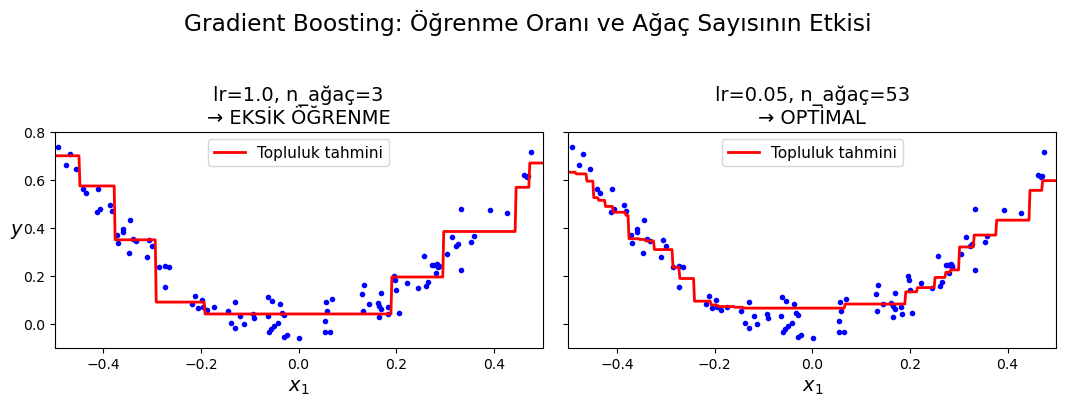

İPUCU: Gradient Boosting aşırı öğreniyorsa → öğrenme oranını AZALT
       (Daha küçük adımlar, daha iyi genelleme)


In [72]:
# ═══════════════════════════════════════════════════════════════
# ÖĞRENME ORANI ETKİSİ GÖRSELLEŞTİRMESİ (Şekil 6-10)
# Az ağaç (eksik öğrenme) vs Erken durdurmaylı optimal ağaç
# ═══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(ncols=2, figsize=(11, 4), sharey=True)

# Sol: Sadece 3 ağaç → yetersiz öğrenme (underfitting)
plt.sca(axes[0])
plot_predictions([gbrt], X, y, axes=[-0.5, 0.5, -0.1, 0.8],
                 style="r-", label="Topluluk tahmini")
plt.title(f"lr={gbrt.learning_rate}, n_ağaç={gbrt.n_estimators_}\n→ EKSİK ÖĞRENME")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)

# Sağ: Erken durdurmayla optimal ağaç sayısı
plt.sca(axes[1])
plot_predictions([gbrt_best], X, y, axes=[-0.5, 0.5, -0.1, 0.8],
                 style="r-", label="Topluluk tahmini")
plt.title(f"lr={gbrt_best.learning_rate}, n_ağaç={gbrt_best.n_estimators_}\n→ OPTİMAL")
plt.xlabel("$x_1$")

plt.suptitle("Gradient Boosting: Öğrenme Oranı ve Ağaç Sayısının Etkisi", y=1.02)
plt.tight_layout()
plt.show()

print("İPUCU: Gradient Boosting aşırı öğreniyorsa → öğrenme oranını AZALT")
print("       (Daha küçük adımlar, daha iyi genelleme)")

---
## 7. Histogram Tabanlı Gradient Boosting (HGB) <a id='hgb'></a>

Büyük veri setleri için optimize edilmiş GBRT uygulaması. Özellikleri **kutucuklara (bins)** ayırarak hem bellek hem hız açısından büyük avantaj sağlar.

| Özellik | GradientBoosting | HistGradientBoosting |
|---------|-----------------|---------------------|
| Büyük veri hızı | Yavaş O(n×m×log m) | Çok Hızlı O(b×m) |
| Eksik değer desteği | ❌ | ✅ |
| Kategorik özellik | ❌ | ✅ |
| Erken durdurma | Manuel | Otomatik (>10K örnek) |

In [73]:
# ═══════════════════════════════════════════════════════════════
# VERİ İNDİRME: CALİFORNİA HOUSING
# ═══════════════════════════════════════════════════════════════

from pathlib import Path
import tarfile
import urllib.request
import pandas as pd
from sklearn.model_selection import train_test_split

def load_housing_data():
    """California Housing veri setini indirir ve yükler."""
    tarball_path = Path("datasets/housing.tgz")

    # Zaten indirilmişse tekrar indirme
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        print("California Housing veri seti indiriliyor...")
        urllib.request.urlretrieve(url, tarball_path)

        # .tgz dosyasını aç
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")

    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()

# %80 eğitim, %20 test
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

# Hedef değişkeni (ev değeri) eğitim setinden ayır
housing_labels = train_set["median_house_value"]
housing = train_set.drop("median_house_value", axis=1)

print(f"✅ Veri seti yüklendi.")
print(f"   Eğitim: {housing.shape}, Hedef: {housing_labels.shape}")
print(f"   Özellikler: {list(housing.columns)}")

California Housing veri seti indiriliyor...
✅ Veri seti yüklendi.
   Eğitim: (16512, 9), Hedef: (16512,)
   Özellikler: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity']


In [76]:
# ═══════════════════════════════════════════════════════════════
# HİSTOGRAM TABANLI GRADIENT BOOSTING REGRESSOR
# ═══════════════════════════════════════════════════════════════

from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import OrdinalEncoder

# 1. Adım: Sütun Dönüştürücü Tanımla
# Sadece "ocean_proximity" sütununu sayıya çeviriyoruz, diğerleri (remainder) aynen geçer.
column_trans = ColumnTransformer(
    [("ocean_encoder", OrdinalEncoder(), ["ocean_proximity"])],
    remainder="passthrough"
)

# 2. Adım: Pipeline Oluştur
# Parametreleri (force_int_remainder_cols gibi) pipeline içinde değil, 
# ilgili fonksiyonların içinde tanımlamalısınız.
hgb_reg = make_pipeline(
    column_trans,
    HistGradientBoostingRegressor(categorical_features=[0], random_state=42)
)

# 3. Modeli Eğit
hgb_reg.fit(housing, housing_labels)

print("✅ HistGradientBoostingRegressor pipeline başarıyla eğitildi.")

✅ HistGradientBoostingRegressor pipeline başarıyla eğitildi.


In [77]:
# ═══════════════════════════════════════════════════════════════
# HGB RMSE DEĞERLENDİRMESİ — ÇAPRAZ DOĞRULAMA
# ═══════════════════════════════════════════════════════════════

from sklearn.model_selection import cross_val_score

# 10 katlı çapraz doğrulama
# scoring="neg_root_mean_squared_error" → RMSE'nin negatifini döner
# (Scikit-Learn convention: yüksek skor = iyi, bu nedenle negatif RMSE)
# Negatifini alınca gerçek RMSE elde edilir
print("10 katlı çapraz doğrulama çalışıyor (bu biraz sürebilir)...")
hgb_rmses = -cross_val_score(
    hgb_reg, housing, housing_labels,
    scoring="neg_root_mean_squared_error",
    cv=10  # 10 katlı çapraz doğrulama
)

# pd.Series().describe(): özet istatistikler
print("\n📊 HGB Regressor RMSE İstatistikleri (10-katlı CV):")
print("-" * 40)
stats = pd.Series(hgb_rmses).describe()
print(stats.to_string())
print(f"\n→ Ortalama RMSE: ${stats['mean']:,.0f}")
print(f"→ Std Sapma   : ${stats['std']:,.0f}")
print("\nNOT: HGB büyük veri setlerinde standart GBRT'den yüzlerce kat daha hızlı!")

10 katlı çapraz doğrulama çalışıyor (bu biraz sürebilir)...

📊 HGB Regressor RMSE İstatistikleri (10-katlı CV):
----------------------------------------
count       10.000000
mean     47613.307194
std       1295.422509
min      44963.213061
25%      47001.233485
50%      48000.963564
75%      48488.093243
max      49176.368465

→ Ortalama RMSE: $47,613
→ Std Sapma   : $1,295

NOT: HGB büyük veri setlerinde standart GBRT'den yüzlerce kat daha hızlı!


---
## 8. Stacking (Yığınlama) <a id='stacking'></a>

**Fikir:** Tahminleri hard/soft voting gibi basit yollarla değil, **başka bir model (blender / meta-öğrenici)** ile birleştir!

```
Giriş → [LR, RF, SVC] → Tahminler → [Blender] → Final Tahmin
```

In [78]:
# ═══════════════════════════════════════════════════════════════
# STACKING SINIFLANDIRICI
# ═══════════════════════════════════════════════════════════════

from sklearn.ensemble import StackingClassifier

# StackingClassifier Parametreleri:
# ─ estimators: Alt katman tahminleyicileri (birinci katman)
#   Her biri bağımsız olarak eğitilir ve tahmin üretir
#
# ─ final_estimator: Blender (meta-öğrenici, ikinci katman)
#   Alt katman tahminlerini girdi olarak alır, final tahmini üretir
#   Varsayılan: StackingClassifier için LogisticRegression
#               StackingRegressor için RidgeCV
#
# ─ cv=5: K-katlı çapraz doğrulama
#   cross_val_predict() ile her eğitim örneği için
#   "örnek dışı" (out-of-sample) tahmin üretilir
#   Blender bu tahminler üzerinde eğitilir → veri sızıntısı önlenir

stacking_clf = StackingClassifier(
    estimators=[
        ('lr',  LogisticRegression(random_state=42)),
        ('rf',  RandomForestClassifier(random_state=42)),
        ('svc', SVC(probability=True, random_state=42))  # Soft için prob=True
    ],
    final_estimator=RandomForestClassifier(random_state=43),  # Blender
    cv=5  # 5 katlı çapraz doğrulama ile blending eğitim seti oluştur
)

# X_train, y_train: önceki Moons veri setinden
stacking_clf.fit(X_train, y_train)

stacking_score = stacking_clf.score(X_test, y_test)
print(f"✅ StackingClassifier eğitildi.")
print(f"   Test doğruluğu: {stacking_score:.3f} (%{stacking_score*100:.1f})")
print(f"   (Soft Voting'in %92.0'ının üzerinde: %{stacking_score*100:.1f})")

# NASIL ÇALIŞIR:
# 1. Her tahminleyici için cross_val_predict() → eğitim setinde OOS tahminler
# 2. Bu tahminler → blender'ın eğitim seti
# 3. Blender eğitilir
# 4. Temel tahminleyiciler tüm eğitim seti üzerinde YENİDEN eğitilir
# (StackingClassifier bunu otomatik yapar)

✅ StackingClassifier eğitildi.
   Test doğruluğu: 0.928 (%92.8)
   (Soft Voting'in %92.0'ının üzerinde: %92.8)


In [79]:
# ═══════════════════════════════════════════════════════════════
# GENEL KARŞILAŞTIRMA: TÜM YÖNTEMLER
# ═══════════════════════════════════════════════════════════════

print("📊 Moons Veri Seti — Tüm Yöntemlerin Test Doğruluğu:")
print("=" * 48)
print(f"  {'Yöntem':<28} {'Doğruluk':>10}")
print("-" * 48)
sonuclar = [
    ("Lojistik Regresyon",  0.864),
    ("Rastgele Orman (tek)", 0.896),
    ("SVM (tek)",           0.896),
    ("Hard Voting",         hard_score),
    ("Soft Voting",         soft_score),
    ("Stacking",            stacking_score),
]
for isim, skor in sonuclar:
    bar = "█" * int(skor * 50 - 42)
    print(f"  {isim:<28} {skor:.3f} {bar}")
print("=" * 48)

📊 Moons Veri Seti — Tüm Yöntemlerin Test Doğruluğu:
  Yöntem                         Doğruluk
------------------------------------------------
  Lojistik Regresyon           0.864 █
  Rastgele Orman (tek)         0.896 ██
  SVM (tek)                    0.896 ██
  Hard Voting                  0.912 ███
  Soft Voting                  0.920 ████
  Stacking                     0.928 ████


---
## 9. Alıştırma Çözümleri 1–7 <a id='cevaplar'></a>

**Soru 1:** Beş farklı modeli tamamen aynı eğitim verisiyle eğittiniz ve hepsi %95 hassasiyet elde etti. Bu modelleri birleştirerek daha iyi sonuç alma şansınız var mı?

**Cevap:** Evet, oylama topluluğu daha iyi sonuç verebilir — modeller birbirinden **yeterince farklıysa** (SVM, Karar Ağacı, Lojistik Regresyon gibi). Aynı veri üzerinde eğitilmiş olmak bir sorun olmayabilir, çünkü farklı algoritmalar farklı türde hatalar yapabilir. Ayrıca modeller farklı eğitim alt kümelerinde eğitilirse (bagging/pasting) bu daha da etkili olur.

**Soru 2:** Hard ve soft voting arasındaki fark nedir?

**Cevap:** Hard voting, her sınıflandırıcının tahminini sayar ve en fazla oyu alan sınıfı seçer. Soft voting, her sınıf için tahmini olasılıkları ortalar ve en yüksek ortalama olasılığa sahip sınıfı seçer. Soft voting, yüksek güvenli oyları daha fazla ağırlıklandırdığı için genellikle daha iyi performans gösterir — ancak tüm modellerin `predict_proba()` metoduna sahip olmasını gerektirir.

**Soru 3:** Bagging topluluğunun eğitimini birden fazla sunucuya dağıtmak mümkün müdür?

**Cevap:** Bagging, Pasting ve Rastgele Ormanlar için evet — her tahminleyici diğerlerinden bağımsızdır, bu nedenle paralel eğitim mümkündür. Boosting için hayır — her tahminleyici bir öncekine dayanır, dolayısıyla sıralı eğitim zorunludur. Stacking için katman içindeki modeller paralelleştirilebilir, ancak bir katman önceki katman tamamlanmadan eğitilemez.

**Soru 4:** Out-of-Bag değerlendirmesinin faydası nedir?

**Cevap:** OOB değerlendirmesi, her tahminleyiciyi eğitilmediği örnekler üzerinde değerlendirir. Bu, ek bir doğrulama setine gerek kalmadan adil bir ensemble değerlendirmesi yapılmasını sağlar. Böylece daha fazla örnek eğitim için kullanılabilir.

**Soru 5:** Extra-Trees'i Rastgele Ormanlardan daha rastgele yapan nedir?

**Cevap:** Rastgele Ormanlarda her düğümde rastgele bir özellik alt kümesi kullanılır. Extra-Trees buna ek olarak **eşikleri de rastgele seçer** (en iyi eşiği aramak yerine). Bu ekstra rastgelelik, bir düzenlileştirme biçimi gibi davranır: Rastgele Orman aşırı öğreniyorsa Extra-Trees daha iyi performans gösterebilir. Ayrıca Extra-Trees eğitim sırasında çok daha **hızlıdır** — en iyi eşiği aramak en zaman alan adımdır. Tahmin hızı ise aynıdır.

**Soru 6:** AdaBoost topluluğunuz yetersiz öğreniyorsa ne yapmalısınız?

**Cevap:** `n_estimators` sayısını artırın, ya da temel tahminleyicinin düzenlileştirme hiperparametrelerini gevşetin. Öğrenme oranını (`learning_rate`) da hafifçe artırmayı deneyebilirsiniz.

**Soru 7:** Gradient Boosting topluluğunuz aşırı öğreniyorsa öğrenme oranını artırmalı mı azaltmalı mısınız?

**Cevap:** Öğrenme oranını **azaltmalısınız**. Ayrıca erken durdurma (`n_iter_no_change`) kullanarak optimal ağaç sayısını bulmayı da deneyin — muhtemelen şu an çok fazla ağaç kullanıyorsunuzdur.

---
## 10. Alıştırma 8 — MNIST Oylama Sınıflandırıcısı <a id='mnist-voting'></a>

**Görev:** MNIST'i eğitim/doğrulama/test olarak böl, çeşitli modeller eğit ve oylama topluluğu ile birleştir.

In [82]:
pip uninstall scikit-learn -y

Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
Note: you may need to restart the kernel to use updated packages.


In [83]:
pip install --no-cache-dir -U scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 49.1 kB/s eta 0:00:0000:0100:07
Note: you may need to restart the kernel to use updated packages.


In [5]:
!conda install -c conda-forge scikit-learn -y


CondaHTTPError: HTTP 000 CONNECTION FAILED for url <https://conda.anaconda.org/conda-forge/osx-64/current_repodata.json>
Elapsed: -

An HTTP error occurred when trying to retrieve this URL.
HTTP errors are often intermittent, and a simple retry will get you on your way.
'https//conda.anaconda.org/conda-forge/osx-64'




In [2]:
!pip install --upgrade scikit-learn

In [80]:
# ═══════════════════════════════════════════════════════════════
# MNIST VERİ SETİ BÖLME
# ═══════════════════════════════════════════════════════════════

# X_mnist ve y_mnist daha önce yüklendi (özellik önemi bölümünde)
# MNIST: ilk 60.000 → eğitim+doğrulama, son 10.000 → test
# (MNIST zaten karıştırılmış halde gelir)

X_train, y_train = X_mnist[:50_000], y_mnist[:50_000]    # 50K eğitim
X_valid, y_valid = X_mnist[50_000:60_000], y_mnist[50_000:60_000]  # 10K doğrulama
X_test,  y_test  = X_mnist[60_000:], y_mnist[60_000:]    # 10K test

print("📊 MNIST Veri Seti Bölünmesi:")
print(f"   Eğitim   : {X_train.shape}")
print(f"   Doğrulama: {X_valid.shape}")
print(f"   Test     : {X_test.shape}")

📊 MNIST Veri Seti Bölünmesi:
   Eğitim   : (50000, 784)
   Doğrulama: (10000, 784)
   Test     : (10000, 784)


In [1]:
# ═══════════════════════════════════════════════════════════════
# BİREYSEL SINIFLANDIRICI TANIMLAMA
# ═══════════════════════════════════════════════════════════════

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier

# 4 farklı sınıflandırıcı tanımlıyoruz
# Her biri farklı bir algoritma → farklı türde hatalar yapar → iyi topluluk çeşitliliği

random_forest_clf = RandomForestClassifier(
    n_estimators=100, random_state=42
)  # Ağaç tabanlı topluluk

extra_trees_clf = ExtraTreesClassifier(
    n_estimators=100, random_state=42
)  # Daha rastgele ağaç topluluğu

svm_clf = LinearSVC(
    max_iter=100,   # Maksimum iterasyon sayısı
    tol=20,         # Yakınsama toleransı (büyük değer → daha hızlı ama daha az hassas)
    dual=True,      # dual=True: n_samples > n_features durumunda (MNIST'te bunun tersi)
    random_state=42
)  # Doğrusal destek vektör makinesi

mlp_clf = MLPClassifier(
    random_state=42
)  # Çok katmanlı algılayıcı (yapay sinir ağı)

print("✅ 4 sınıflandırıcı tanımlandı:")
print("   1. RandomForestClassifier")
print("   2. ExtraTreesClassifier")
print("   3. LinearSVC")
print("   4. MLPClassifier")

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
# ═══════════════════════════════════════════════════════════════
# TÜM SINIFLANDIRICI EĞİTİMİ
# ═══════════════════════════════════════════════════════════════

# Sınıflandırıcıları liste olarak sakla
estimators = [random_forest_clf, extra_trees_clf, svm_clf, mlp_clf]

print("Sınıflandırıcılar eğitiliyor (bu birkaç dakika sürebilir)...")
for estimator in estimators:
    print(f"  Eğitiliyor: {type(estimator).__name__}...")
    estimator.fit(X_train, y_train)  # 50K örnek üzerinde eğit
    print(f"  ✅ Tamamlandı.")

print("\nTüm modeller eğitildi!")

In [ ]:
# ═══════════════════════════════════════════════════════════════
# BİREYSEL SINIFLANDIRICI DOĞRULAMA SETI PERFORMANSI
# ═══════════════════════════════════════════════════════════════

print("📊 Bireysel Sınıflandırıcı — Doğrulama Seti Doğrulukları:")
print("-" * 50)

bireysel_skorlar = [estimator.score(X_valid, y_valid) for estimator in estimators]
for clf, skor in zip(estimators, bireysel_skorlar):
    print(f"  {type(clf).__name__:25s}: %{skor*100:.2f}")

# Beklenen (yaklaşık):
# RandomForestClassifier: ~%96.7
# ExtraTreesClassifier  : ~%96.8
# LinearSVC             : ~%86.4  ← diğerlerinden çok geride!
# MLPClassifier         : ~%96.9
print("\nNOT: LinearSVC diğerlerinden çok geride kalıyor.")

In [ ]:
# ═══════════════════════════════════════════════════════════════
# OYLAMA SINIFLANDIRICI KURULUMU VE EĞİTİMİ
# ═══════════════════════════════════════════════════════════════

from sklearn.ensemble import VotingClassifier

# (isim, model) çiftlerinden oluşan liste
named_estimators = [
    ("random_forest_clf", random_forest_clf),
    ("extra_trees_clf",   extra_trees_clf),
    ("svm_clf",           svm_clf),
    ("mlp_clf",           mlp_clf),
]

# Varsayılan: voting='hard' (çoğunluk oyu)
voting_clf = VotingClassifier(named_estimators)

print("Oylama sınıflandırıcısı eğitiliyor...")
# NOT: VotingClassifier, her modelin bir KOPYASINI oluşturur
# ve bu kopyaları class index etiketleriyle eğitir
# (orijinal string etiketler değil, sayısal index'ler)
voting_clf.fit(X_train, y_train)
print("✅ Eğitim tamamlandı.")

In [ ]:
# ═══════════════════════════════════════════════════════════════
# OYLAMA SINIFLANDIRICI DOĞRULAMA PERFORMANSI
# ═══════════════════════════════════════════════════════════════

voting_valid_score = voting_clf.score(X_valid, y_valid)
print(f"Oylama Sınıflandırıcı doğruluğu (doğrulama): %{voting_valid_score*100:.2f}")

In [ ]:
# ═══════════════════════════════════════════════════════════════
# ETİKET KODLAMA — NEDEN GEREKLİ?
# ═══════════════════════════════════════════════════════════════

# VotingClassifier, klon modelleri class INDEX ile eğitir
# Orijinal y_valid: string sınıf adları ("0", "1", ..., "9")
# Klon modeller: sayısal index bekler
# → Değerlendirme için y_valid'i dönüştürmeliyiz

# Yöntem 1: LabelEncoder (genel yaklaşım)
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
y_valid_encoded_v1 = encoder.fit_transform(y_valid)
print("LabelEncoder ile dönüşüm:")
print(f"  Orijinal: {y_valid[:5].tolist()}")
print(f"  Dönüştürülmüş: {y_valid_encoded_v1[:5].tolist()}")

# Yöntem 2: MNIST için daha basit (rakamlar zaten sayısal)
import numpy as np
y_valid_encoded = y_valid.astype(np.int64)
print(f"\nDirek dönüşüm (MNIST için): {y_valid_encoded[:5].tolist()}")

In [ ]:
# ═══════════════════════════════════════════════════════════════
# KLON MODEL DOĞRULUKLARI
# ═══════════════════════════════════════════════════════════════

# voting_clf.estimators_: VotingClassifier'ın eğitilmiş KLON modelleri
# (orijinal estimators değil, kopyalar)
print("📊 VotingClassifier Klonlarının Doğruluğu:")
print("-" * 45)
klon_skorlar = [est.score(X_valid, y_valid_encoded) for est in voting_clf.estimators_]
for isim, skor in zip([n for n,_ in named_estimators], klon_skorlar):
    print(f"  {isim:25s}: %{skor*100:.2f}")

In [ ]:
# ═══════════════════════════════════════════════════════════════
# ZAYIF MODELI (LinearSVC) ÇIKARMA
# ═══════════════════════════════════════════════════════════════

# LinearSVC diğerlerinden çok geride → topluluğa katkısı negatif olabilir
# set_params() → belirli bir tahmini "drop" yaparak devre dışı bırak
voting_clf.set_params(svm_clf="drop")
print("SVM 'drop' olarak ayarlandı.")

# Dikkat: set_params() sadece estimators listesini günceller
print(f"\nvoting_clf.estimators (güncellendi):")
print(f"  {[n for n,_ in voting_clf.estimators]}")

# Ancak eğitilmiş klon listesi (estimators_) güncellenmedi!
print(f"\nvoting_clf.estimators_ (GÜNCELLENMEDI — hâlâ 4 model var):")
print(f"  {[type(e).__name__ for e in voting_clf.estimators_]}")

In [ ]:
# ═══════════════════════════════════════════════════════════════
# EĞİTİLMİŞ KLON LİSTESİNDEN DE SVM'İ ÇIKAR
# ═══════════════════════════════════════════════════════════════

# named_estimators_: isim → eğitilmiş klon sözlüğü
# .pop("svm_clf"): sözlükten çıkar VE çıkarılan değeri döner
svm_clf_trained = voting_clf.named_estimators_.pop("svm_clf")

# estimators_: eğitilmiş klonların listesi
# .remove(svm_clf_trained): bu nesneyi listeden çıkar
voting_clf.estimators_.remove(svm_clf_trained)

print(f"SVM hem estimators_ hem de named_estimators_'dan çıkarıldı.")
print(f"Kalan modeller: {[type(e).__name__ for e in voting_clf.estimators_]}")

# Yeniden değerlendir
svm_cikari_skor = voting_clf.score(X_valid, y_valid)
print(f"\n📊 SVM Çıkarıldıktan Sonra Doğrulama Doğruluğu: %{svm_cikari_skor*100:.2f}")
print(f"   Önceki (SVM dahil): %{voting_valid_score*100:.2f}")
print(f"   Değişim: {(svm_cikari_skor - voting_valid_score)*100:+.2f} puan")

In [ ]:
# ═══════════════════════════════════════════════════════════════
# SOFT VOTING DENEMESİ
# ═══════════════════════════════════════════════════════════════

# voting="soft" olarak değiştir (yeniden eğitim gerekmez!)
voting_clf.voting = "soft"

soft_valid_skor = voting_clf.score(X_valid, y_valid)
print(f"Soft Voting Doğruluğu: %{soft_valid_skor*100:.2f}")
print(f"Hard Voting Doğruluğu: %{svm_cikari_skor*100:.2f}")

if svm_cikari_skor > soft_valid_skor:
    print("\n→ Bu durumda HARD VOTING daha iyi! (Her zaman soft daha iyi değil)")
else:
    print("\n→ SOFT VOTING daha iyi!")

In [ ]:
# ═══════════════════════════════════════════════════════════════
# FİNAL TEST SETİ DEĞERLENDİRMESİ
# ═══════════════════════════════════════════════════════════════

# Hard voting'e geri dön (daha iyi sonuç vermişti)
voting_clf.voting = "hard"

test_skor = voting_clf.score(X_test, y_test)
print(f"🏆 Oylama Sınıflandırıcı (Hard, SVM çıkarılmış) — TEST DOĞRULUĞU: %{test_skor*100:.2f}")

print("\n📊 Bireysel Modeller — Test Doğrulukları:")
print("-" * 45)
bireysel_test = [est.score(X_test, y_test.astype(np.int64)) for est in voting_clf.estimators_]
for est, skor in zip(voting_clf.estimators_, bireysel_test):
    print(f"  {type(est).__name__:25s}: %{skor*100:.2f}")

en_iyi_bireysel = max(bireysel_test)
print(f"\n  En iyi bireysel: %{en_iyi_bireysel*100:.2f}")
print(f"  Oylama topluluğu: %{test_skor*100:.2f}")
print(f"  Hata azalması: {(1-en_iyi_bireysel)/(1-test_skor) - 1:.0%} daha az hata!")

---
## 11. Alıştırma 9 — MNIST Stacking Ensemble <a id='mnist-stacking'></a>

**Görev:** Bireysel sınıflandırıcıların doğrulama seti tahminlerini toplayıp bu tahminleri eğitmek için bir **blender** oluştur.

In [ ]:
# ═══════════════════════════════════════════════════════════════
# BLENDING EĞİTİM SETİ OLUŞTURMA
# ═══════════════════════════════════════════════════════════════

# Her eğitim örneği için tüm sınıflandırıcıların tahminlerini topla
# Sonuç: (10000, 4) matris → 10K örnek × 4 sınıflandırıcı tahmini

X_valid_predictions = np.empty(
    (len(X_valid), len(estimators)),  # (10000, 4)
    dtype=object  # String etiketleri tutabilmek için object
)

print("Doğrulama seti tahminleri toplanıyor...")
for index, estimator in enumerate(estimators):
    X_valid_predictions[:, index] = estimator.predict(X_valid)
    print(f"  ✅ {type(estimator).__name__}: tamamlandı")

print(f"\nBlending eğitim seti boyutu: {X_valid_predictions.shape}")
print(f"İlk 3 örnek için tahminler:")
print(X_valid_predictions[:3])

# Her satır: bir görüntü için 4 modelin tahmini
# Örn: ['3', '3', '3', '3'] → 4 model de aynı fikirde
# Örn: ['5', '5', '8', '5'] → 3'e 1, blender 5'e oy vermelidir

In [ ]:
# ═══════════════════════════════════════════════════════════════
# BLENDER EĞİTİMİ
# ═══════════════════════════════════════════════════════════════

# Blender: tahminleri birleştiren meta-öğrenici
# Giriş: 4 sınıflandırıcının tahminleri (X_valid_predictions)
# Hedef: Gerçek etiketler (y_valid)
# OOB skoru ile performansı ön-değerlendir

rnd_forest_blender = RandomForestClassifier(
    n_estimators=200,
    oob_score=True,   # OOB ile kendi kendini değerlendir
    random_state=42
)
rnd_forest_blender.fit(X_valid_predictions, y_valid)

print(f"✅ Blender (RandomForest) eğitildi.")
print(f"   OOB Skoru: %{rnd_forest_blender.oob_score_*100:.2f}")
print(f"\nİPUCU: Blender'ı ince ayarlayabilir veya farklı blender")
print(f"       türleri (MLPClassifier gibi) deneyebilirsiniz.")

In [ ]:
# ═══════════════════════════════════════════════════════════════
# TEST SETİNDE STACKING ENSEMBLE DEĞERLENDİRMESİ
# ═══════════════════════════════════════════════════════════════

# 1. Adım: Her test örneği için tüm sınıflandırıcıların tahminlerini al
X_test_predictions = np.empty(
    (len(X_test), len(estimators)),  # (10000, 4)
    dtype=object
)

print("Test seti tahminleri toplanıyor...")
for index, estimator in enumerate(estimators):
    X_test_predictions[:, index] = estimator.predict(X_test)
    print(f"  ✅ {type(estimator).__name__}: tamamlandı")

# 2. Adım: Blender'a tahminleri besle → final tahmin al
y_pred = rnd_forest_blender.predict(X_test_predictions)

# 3. Adım: Doğruluğu değerlendir
stacking_skor = accuracy_score(y_test, y_pred)
print(f"\n📊 Manuel Stacking Ensemble — Test Doğruluğu: %{stacking_skor*100:.2f}")
print(f"   Oylama Sınıflandırıcısı             : %{test_skor*100:.2f}")

if test_skor > stacking_skor:
    print(f"\n→ Oylama daha iyi! Manuel stacking bu durumda dezavantajlı.")
    print(f"   Neden? Blender sadece 10K doğrulama örnekliyle eğitildi.")

In [ ]:
# ═══════════════════════════════════════════════════════════════
# SCİKİT-LEARN StackingClassifier İLE DAHA İYİ STACKING
# ═══════════════════════════════════════════════════════════════

# StackingClassifier K-Katlı çapraz doğrulama kullandığından
# ayrı doğrulama setine gerek yok!
# → Eğitim + doğrulama setlerini birleştirip daha büyük eğitim seti kullanalım

X_train_full = X_mnist[:60_000]  # 60K örnek (50K eğitim + 10K doğrulama)
y_train_full = y_mnist[:60_000]

print(f"Tam eğitim seti: {X_train_full.shape} (doğrulama seti de dahil)")

# StackingClassifier oluştur
stack_clf = StackingClassifier(
    named_estimators,                          # Alt katman: 4 sınıflandırıcı
    final_estimator=rnd_forest_blender        # Blender: RandomForest
    # cv=5 varsayılan: 5 katlı çapraz doğrulama ile OOS tahminler üretilir
)

print("\n⚠️  UYARI: Aşağıdaki eğitim 15-30 dakika sürebilir!")
print("   (4 model × 5 kat + 4 model × 1 tam eğitim + 1 blender = 25 model)")
print("")
print("   Eğitim başlıyor...")
stack_clf.fit(X_train_full, y_train_full)
print("   ✅ Eğitim tamamlandı!")

In [ ]:
# ═══════════════════════════════════════════════════════════════
# SCİKİT-LEARN STACKING — TEST DOĞRULUĞU
# ═══════════════════════════════════════════════════════════════

sklearn_stacking_skor = stack_clf.score(X_test, y_test)

print("🏆 SONUÇLAR — Tüm Yöntemlerin Karşılaştırması:")
print("=" * 55)
sonuclar = [
    ("Manuel Stacking",       stacking_skor),
    ("Oylama (Hard, SVM yok)", test_skor),
    ("Scikit-Learn Stacking", sklearn_stacking_skor),
]
for isim, skor in sorted(sonuclar, key=lambda x: x[1]):
    print(f"  {isim:30s}: %{skor*100:.2f}")
print("=" * 55)

print("")
print("NEDEN Scikit-Learn Stacking Daha İyi?")
print("-" * 40)
print("1. Doğrulama setini geri kazanarak DAHA BÜYÜK eğitim seti kullandı")
print("   (10K daha fazla örnek blender için mevcut)")
print("2. predict_proba() varsa kullandı, yoksa decision_function()")
print("   → Blender daha nüanslı, olasılık tabanlı girdilerle çalıştı")
print("   → Manuel stacking yalnızca sınıf etiketleri (sert tahmin) kullandı")